In [1]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [2]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


import xgboost as xgb

In [3]:
df_1998_2017 = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_1998_2017

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [4]:
print(f"total number of rows and columns in the dataset: {len(df_1998_2017.columns)} columns, {len(df_1998_2017)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [5]:
## Grouping years into decodes
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_1998_2017)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [6]:
df_Makedatetime[df_Makedatetime['Year'] == 1998].describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,5.000000,5.000000,5.000000,5,5.000000e+00,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0
mean,7269.400000,6.286389,92.961833,1998-09-14 19:12:00,1.998092e+07,6.200000,3.350000,293.484000,301.964500,301.464250,...,-1.281500,4.075000,1.760500,8.27500,0.600000,1.274000,1.232500,10.746000,0.365500,1998.0
min,4512.000000,-12.094722,72.768889,1998-08-23 00:00:00,1.998082e+07,3.000000,1.000000,262.150000,300.630000,300.340000,...,-1.460000,2.000000,1.200000,7.00000,0.000000,0.000000,0.730000,4.900000,0.210000,1998.0
25%,5044.000000,10.517222,72.768889,1998-08-29 00:00:00,1.998083e+07,3.000000,1.000000,299.270000,301.070000,301.580000,...,-1.337500,4.000000,1.200000,7.00000,0.000000,0.000000,0.730000,4.900000,0.210000,1998.0
50%,7683.000000,10.618333,96.843333,1998-09-20 00:00:00,1.998092e+07,5.000000,3.000000,301.980000,301.070000,301.580000,...,-1.260000,4.000000,1.960000,8.37500,1.000000,0.000000,1.522500,11.480000,0.430000,1998.0
75%,7684.000000,11.195556,103.291667,1998-10-02 00:00:00,1.998100e+07,10.000000,3.000000,302.010000,302.812500,301.640000,...,-1.260000,5.000000,1.962500,9.00000,1.000000,0.000000,1.570000,13.070000,0.467500,1998.0
max,11424.000000,11.195556,119.136389,1998-10-02 00:00:00,1.998100e+07,10.000000,8.750000,302.010000,304.240000,302.181250,...,-1.090000,5.375000,2.480000,10.00000,1.000000,6.370000,1.610000,19.380000,0.510000,1998.0
std,2745.875052,10.280209,20.139444,NaN,8.806645e+01,3.563706,3.180016,17.556087,1.523003,0.677442,...,0.134717,1.309819,0.553761,1.30024,0.547723,2.848751,0.459762,6.099941,0.144745,0.0


In [7]:
df_Makedatetime[df_Makedatetime['Year'] == 2000].describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,2.000000,2.000000,2.000000,2,2.000000e+00,2.0,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.0,2.000000,2.000000,2.000000,2.0
mean,6841.000000,-17.485833,-149.833611,2000-07-24 00:00:00,2.000072e+07,2.0,2.500000,299.630000,300.060000,300.770000,...,-1.260000,0.500000,1.180000,4.500000,0.0,0.0,0.925000,8.215000,0.270000,2000.0
min,6830.000000,-17.496389,-149.863056,2000-06-21 00:00:00,2.000062e+07,2.0,0.000000,299.580000,299.510000,300.760000,...,-1.280000,0.000000,1.130000,4.000000,0.0,0.0,0.850000,7.320000,0.210000,2000.0
25%,6835.500000,-17.491111,-149.848333,2000-07-07 12:00:00,2.000067e+07,2.0,1.250000,299.605000,299.785000,300.765000,...,-1.270000,0.250000,1.155000,4.250000,0.0,0.0,0.887500,7.767500,0.240000,2000.0
50%,6841.000000,-17.485833,-149.833611,2000-07-24 00:00:00,2.000072e+07,2.0,2.500000,299.630000,300.060000,300.770000,...,-1.260000,0.500000,1.180000,4.500000,0.0,0.0,0.925000,8.215000,0.270000,2000.0
75%,6846.500000,-17.480556,-149.818889,2000-08-09 12:00:00,2.000077e+07,2.0,3.750000,299.655000,300.335000,300.775000,...,-1.250000,0.750000,1.205000,4.750000,0.0,0.0,0.962500,8.662500,0.300000,2000.0
max,6852.000000,-17.475278,-149.804167,2000-08-26 00:00:00,2.000083e+07,2.0,5.000000,299.680000,300.610000,300.780000,...,-1.240000,1.000000,1.230000,5.000000,0.0,0.0,1.000000,9.110000,0.330000,2000.0
std,15.556349,0.014928,0.041641,NaN,1.449569e+02,0.0,3.535534,0.070711,0.777817,0.014142,...,0.028284,0.707107,0.070711,0.707107,0.0,0.0,0.106066,1.265721,0.084853,0.0


In [8]:
df_Makedatetime[df_Makedatetime['Year'] == 2001].describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,3.000000,3.000000,3.000000,3,3.000000e+00,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.0,3.000000,3.000000,3.0,3.0,3.00000,3.000000,3.000000,3.0
mean,7001.666667,-16.839444,-151.113491,2001-09-07 00:00:00,2.001088e+07,1.833333,1.666667,300.483333,300.636667,300.843333,...,-1.173333,0.0,1.146667,5.000000,0.0,0.0,0.88000,7.076667,0.296667,2001.0
min,6853.000000,-17.475278,-151.809278,2001-06-15 00:00:00,2.001062e+07,1.500000,0.000000,299.810000,300.140000,300.760000,...,-1.240000,0.0,1.030000,4.000000,0.0,0.0,0.80000,6.250000,0.270000,2001.0
25%,6911.500000,-17.008833,-151.768153,2001-07-17 12:00:00,2.001072e+07,1.750000,0.000000,299.920000,300.325000,300.820000,...,-1.200000,0.0,1.080000,4.000000,0.0,0.0,0.82000,6.785000,0.280000,2001.0
50%,6970.000000,-16.542389,-151.727028,2001-08-19 00:00:00,2.001082e+07,2.000000,0.000000,300.030000,300.510000,300.880000,...,-1.160000,0.0,1.130000,4.000000,0.0,0.0,0.84000,7.320000,0.290000,2001.0
75%,7076.000000,-16.521528,-150.765597,2001-10-19 00:00:00,2.001102e+07,2.000000,2.500000,300.820000,300.885000,300.885000,...,-1.140000,0.0,1.205000,5.500000,0.0,0.0,0.92000,7.490000,0.310000,2001.0
max,7182.000000,-16.500667,-149.804167,2001-12-19 00:00:00,2.001122e+07,2.000000,5.000000,301.610000,301.260000,300.890000,...,-1.120000,0.0,1.280000,7.000000,0.0,0.0,1.00000,7.660000,0.330000,2001.0
std,166.770301,0.551043,1.134653,NaN,3.072545e+02,0.288675,2.886751,0.981903,0.570643,0.072342,...,0.061101,0.0,0.125831,1.732051,0.0,0.0,0.10583,0.735822,0.030551,0.0


In [9]:
df_Makedatetime[df_Makedatetime['Year'] == 2002].describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,63.000000,63.000000,63.000000,63,6.300000e+01,63.000000,63.000000,63.000000,63.000000,63.000000,...,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.0
mean,6443.365079,0.349513,87.048047,2002-08-06 14:28:34.285714304,2.002078e+07,5.155556,1.330476,293.046825,300.875205,299.436052,...,-2.600622,0.888889,1.757897,7.719577,1.099206,0.220754,1.405384,10.904841,0.525139,2002.0
min,5101.000000,-17.475278,-151.809278,2002-03-11 00:00:00,2.002031e+07,0.600000,0.000000,262.150000,299.050000,296.820000,...,-5.150000,0.000000,1.030000,4.000000,0.000000,0.000000,0.800000,6.250000,0.270000,2002.0
25%,5345.000000,-16.800117,114.299819,2002-06-20 12:00:00,2.002062e+07,2.300000,0.000000,298.465000,299.890000,297.040000,...,-4.920000,0.000000,1.390000,6.000000,1.000000,0.000000,1.007500,7.530000,0.395000,2002.0
50%,6378.000000,-16.500667,114.384639,2002-07-28 00:00:00,2.002073e+07,5.000000,0.000000,299.900000,300.710000,300.380000,...,-1.552500,1.000000,1.600000,7.000000,1.000000,0.000000,1.060000,9.170000,0.440000,2002.0
75%,6878.500000,22.365750,178.274000,2002-09-15 00:00:00,2.002092e+07,10.000000,0.000000,301.770000,301.663333,300.870000,...,-1.170000,1.750000,2.255000,9.000000,1.000000,0.000000,1.705000,12.780000,0.630000,2002.0
max,10975.000000,22.551139,178.327778,2002-12-31 00:00:00,2.002123e+07,10.000000,70.000000,302.380000,303.270000,302.190000,...,-0.340000,4.000000,3.007500,15.000000,2.000000,3.280000,3.077500,22.822500,1.060000,2002.0
std,1411.757773,18.326751,119.806467,NaN,1.912982e+02,3.381056,8.838434,15.173865,1.139096,1.949854,...,1.859358,0.938403,0.526818,2.636434,0.530406,0.684880,0.567131,4.067311,0.207261,0.0


In [10]:
df_Makedatetime[['Ecoregion']].value_counts()

Ecoregion                                  
Sunda Shelf, south-east Asia                   1000
Sulu Sea                                        661
South-east Philippines                          619
Hispaniola, Puerto Rico and Lesser Antilles     583
Society Islands, French Polynesia               518
                                               ... 
South China Sea                                   1
Samoa, Tuvalu and Tonga                           1
Houtman Abrolhos Islands, west Australia          1
North Mozambique coast                            1
Birds Head Peninsula, Papua                       1
Name: count, Length: 80, dtype: int64

In [11]:
print(f"total number of rows and columns in the dataset: {len(df_Makedatetime.columns)} columns, {len(df_Makedatetime)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 49 columns, 9665 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


##

## Data Analysis and Cleaning data

In [12]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

In [13]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()

In [14]:
Missing  = nan_check(df_Makedatetime)


In [15]:
Missing

,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [16]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_1998_2017, '%')
print("Missing values more than 0.4% : Delete")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

### วิเคราะห์ตัวเเปรที่เป็น Object

In [17]:
df_Makedatetime[['Realm']].value_counts()

Realm                     
Central Indo-Pacific          5420
Tropical Atlantic             1915
Western Indo-Pacific          1264
Eastern Indo-Pacific           670
Temperate Australasia          266
Temperate Northern Pacific     113
Tropical Eastern Pacific        17
Name: count, dtype: int64

In [18]:
df_Makedatetime[['Year']].value_counts()

Year
2006    850
2004    731
2009    721
2005    700
2008    692
2007    643
2013    626
2016    619
2015    615
2014    600
2003    599
2012    563
2017    562
2010    538
2011    533
2002     63
1998      5
2001      3
2000      2
Name: count, dtype: int64

### ฟังชันก์สำหรับการใช้วัดผลของ RandomForest

In [19]:
def PLOTING_RESULT(pred,actual):
    y_test = actual.ravel()
    y_test_pred = pred.ravel()

    plt.figure(figsize=(10,6))

    plt.scatter(range(len(y_test)), y_test, 
                color='red', alpha=1, label='Actual values')

    plt.scatter(range(len(y_test_pred)), y_test_pred, 
                color='green', alpha=0.8, label='Predicted Values')

    plt.xlabel('Sample Index')
    plt.ylabel('Bleaching Percent')
    plt.title('Random Forest Prediction vs Actual Values')

    plt.legend()
    plt.show()

In [20]:
def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)).round(3)}") # score from training
    pred = model.predict(X_test)
    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print("Test MSE:", test_mse.round(3))
    print("-" * 30)


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse.round(3)}")
    print("-" * 30)

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2.round(3)}")
    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae.round(3)}")
    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape.round(3)}")
    print("-" * 30)
    
    print(pred.shape)
    print(y_test.shape)



In [21]:
def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)

In [22]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)

##

#### Clean data from paper

In [23]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

In [24]:
col_dont_need = ['ID', 'Date', 'Date2', 'Latitude_Degrees', 'Longitude_Degrees', 'Year' , 'SSTA_Mean']
df_experimenttwo = Clean_data_paper(df_Makedatetime, col_object, col_dont_need)

C:\Users\superuser\AppData\Local\Temp\ipykernel_10436\2597983376.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN


In [25]:
df_already_filledEXtwo = df_experimenttwo.fillna(method='ffill')

C:\Users\superuser\AppData\Local\Temp\ipykernel_10436\1583712956.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_already_filledEXtwo = df_experimenttwo.fillna(method='ffill')


## ตัวแปรที่ใช้ในการทดลองที่ 2 คือ df_already_filledEXTwo

In [26]:
print(f"total number of rows and columns in the dataset: {len(df_already_filledEXtwo.columns)} columns, {len(df_already_filledEXtwo)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 34 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


In [27]:
def Grouping_data(df, col_groupby, name_new_col, cols_keep=None):
    df_new = df.copy()
    df_new = df_new[col_groupby]
    print(f"Groupby name is : {name_new_col}")
    
    return df_new

In [28]:
col_Other = [ 'Depth_m', 'ClimSST', 'Windspeed'] # Exposure is object
df_Other_groupby = Grouping_data(df_already_filledEXtwo, col_Other, 'Other_groupby')

Groupby name is : Other_groupby


In [29]:
col_SSTA = ['SSTA', 
            #'SSTA_Mean', 
            'SSTA_Minimum', 
            'SSTA_Maximum', 
            'SSTA_Standard_Deviation',
            'SSTA_Frequency',
            'SSTA_Frequency_Standard_Deviation',
            'SSTA_FrequencyMax',
            'SSTA_FrequencyMean',
            'SSTA_DHW',
            'SSTA_DHW_Standard_Deviation',
            'SSTA_DHWMax',
            'SSTA_DHWMean',
        ]
df_SSTA_groupby = Grouping_data(df_already_filledEXtwo, col_SSTA, 'SSTA_groupby')

Groupby name is : SSTA_groupby


In [30]:
col_temperature = [
                    'Temperature_Kelvin', 
                    'Temperature_Mean', 
                    'Temperature_Minimum', 
                    'Temperature_Maximum', 
                    'Temperature_Kelvin_Standard_Deviation'
                  ]
df_temperature_groupby = Grouping_data(df_already_filledEXtwo, col_temperature, 'temperature_groupby')

Groupby name is : temperature_groupby


In [31]:
col_TSA = [
           
           'TSA',
           'TSA_Standard_Deviation',
           'TSA_Minimum',
           'TSA_Maximum',
           'TSA_Mean',
           'TSA_Frequency',
           'TSA_Frequency_Standard_Deviation',
           'TSA_FrequencyMax',
           'TSA_FrequencyMean',
           'TSA_DHW',
           'TSA_DHW_Standard_Deviation',
           'TSA_DHWMax',
           'TSA_DHWMean'
        ]
df_TSA_groupby = Grouping_data(df_already_filledEXtwo, col_TSA, 'TSA_groupby')

Groupby name is : TSA_groupby


In [32]:
print(f"Checking all columns : {len(col_Other) + len(col_SSTA) + len(col_temperature) + len(col_TSA)}")
print("คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้")

Checking all columns : 33
คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้


In [33]:
print(df_Other_groupby.isnull().sum())
print("-"*50)
print(df_SSTA_groupby.isnull().sum())
print("-" * 50)
print(df_temperature_groupby.isnull().sum())


Depth_m      0
ClimSST      0
Windspeed    0
dtype: int64
--------------------------------------------------
SSTA                                 0
SSTA_Minimum                         0
SSTA_Maximum                         0
SSTA_Standard_Deviation              0
SSTA_Frequency                       0
SSTA_Frequency_Standard_Deviation    0
SSTA_FrequencyMax                    0
SSTA_FrequencyMean                   0
SSTA_DHW                             0
SSTA_DHW_Standard_Deviation          0
SSTA_DHWMax                          0
SSTA_DHWMean                         0
dtype: int64
--------------------------------------------------
Temperature_Kelvin                       0
Temperature_Mean                         0
Temperature_Minimum                      0
Temperature_Maximum                      0
Temperature_Kelvin_Standard_Deviation    0
dtype: int64


In [34]:
print("-" * 50)
print(df_TSA_groupby.isnull().sum())

--------------------------------------------------
TSA                                 0
TSA_Standard_Deviation              0
TSA_Minimum                         0
TSA_Maximum                         0
TSA_Mean                            0
TSA_Frequency                       0
TSA_Frequency_Standard_Deviation    0
TSA_FrequencyMax                    0
TSA_FrequencyMean                   0
TSA_DHW                             0
TSA_DHW_Standard_Deviation          0
TSA_DHWMax                          0
TSA_DHWMean                         0
dtype: int64


## Groupby data reduce dimentional use Principle component Analysis (PCA)

In [35]:
from sklearn.decomposition import PCA

In [36]:
# Groupby data
def Groupby_values_data(df):
    return df.values


df_Other_values = Groupby_values_data(df_Other_groupby)
df_SSTA_values = Groupby_values_data(df_SSTA_groupby)
df_temperature_values = Groupby_values_data(df_temperature_groupby)
df_TSA_values = Groupby_values_data(df_TSA_groupby)

In [37]:
scaler = StandardScaler()
X_Otherscalered = scaler.fit_transform(df_Other_values)
X_SSTAscalered = scaler.fit_transform(df_SSTA_values)
X_temperaturescalered = scaler.fit_transform(df_temperature_values)
X_TSAscalered = scaler.fit_transform(df_TSA_values)

In [38]:
## PCA of df_Others
pca = PCA(n_components= X_Otherscalered.shape[1])

pca.fit_transform(X_Otherscalered)
print(f"Explained_variance (n_components = {pca.n_components}) = {pca.explained_variance_}") # Eigenvalues
print("-" * 100)
print(f"Explaned_variance_ratio (n_components = {pca.n_components}) = {pca.explained_variance_ratio_}") # Variance Ratio
print("-" * 100)
print(f"Total explained variance ratio: {np.sum(pca.explained_variance_ratio_).round(4)}")

Explained_variance (n_components = 3) = [1.12377494 0.99963091 0.87708507]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 3) = [0.37453036 0.33315579 0.29231386]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 1.0


In [39]:
def scree_plot(X, n_components, with_cumulative=False, show_data_label=False, figsize=(10, 7)):
    '''
    PCA scree plot with cumulative
    '''
    scaler = StandardScaler()
    X_t=scaler.fit_transform(X)

    max_components = min(X.shape)
    x=np.arange(1, n_components+1)
    pca = PCA(n_components=max_components)
    pca.fit_transform(X_t)
    y1=pca.explained_variance_ratio_[:n_components]
    y2=np.cumsum(pca.explained_variance_ratio_)[:n_components]
    
    plt.figure(figsize=figsize)
    
    if n_components > 20:
        marker = None
    else:
        marker = 'o'
    if with_cumulative:
        plt.plot(x, y2, linestyle='--', marker=marker, label='cumulative', color='salmon')
        
    plt.plot(x, y1, linestyle='-', marker=marker, label='individual', color='deepskyblue')
    plt.title('explained variance ratio')
    plt.xlabel('# of components')
    plt.ylabel('proportion of variance explained')
    plt.legend()
    if with_cumulative:
        [plt.axhline(y=xl, color='.7', linestyle='--') for xl in [.8, .9, .95, 1]]
    plt.grid(axis='x')

    if show_data_label:
        for n, v, cv in zip(np.nditer(x, flags=['refs_ok']), 
                            np.nditer(y1, flags=['refs_ok']),
                            np.nditer(y2, flags=['refs_ok'])):
                plt.text(n+.02, v+.02, f'{v*100:.2f}%', fontsize=10)
                if with_cumulative:
                    plt.text(n+.02, cv+.02, f'{cv*100:.2f}%', fontsize=10)

In [40]:
def discover_optimal_PCA_components(X, threshold= 0.95):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=X_scaled.shape[1])
    pca.fit_transform(X_scaled)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance >= threshold) + 1
    
    return optimal_components

In [41]:
optimal_n_components_other = discover_optimal_PCA_components(X_Otherscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_other}")

Optimal number of PCA components to retain at least 95% vaeriance: 3


In [42]:
optimal_n_components_SSTA = discover_optimal_PCA_components(X_SSTAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_SSTA}")

Optimal number of PCA components to retain at least 95% vaeriance: 7


In [43]:
optimal_n_components_temp = discover_optimal_PCA_components(X_temperaturescalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_temp}")

Optimal number of PCA components to retain at least 95% vaeriance: 3


In [44]:
optimal_n_components_TSA = discover_optimal_PCA_components(X_TSAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_TSA}")

Optimal number of PCA components to retain at least 95% vaeriance: 7


Explained_variance (n_components = 3) = [1.12377494 0.99963091 0.87708507]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 3) = [0.37453036 0.33315579 0.29231386]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 1.0


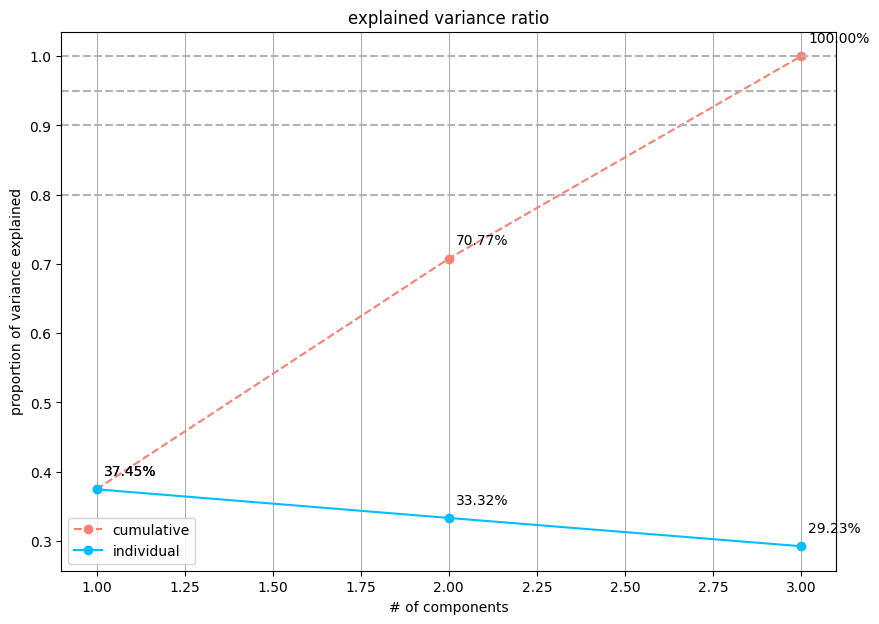

In [45]:
pca = PCA(n_components= optimal_n_components_other)

pca.fit_transform(X_Otherscalered)
print(f"Explained_variance (n_components = {pca.n_components}) = {pca.explained_variance_}") # Eigenvalues
print("-" * 100)
print(f"Explaned_variance_ratio (n_components = {pca.n_components}) = {pca.explained_variance_ratio_}") # Variance Ratio
print("-" * 100)
print(f"Total explained variance ratio: {np.sum(pca.explained_variance_ratio_).round(4)}")
scree_plot(X_Otherscalered, X_Otherscalered.shape[1], True, True)

Explained_variance (n_components = 7) = [6.40072153 1.41634167 1.29928099 0.79293771 0.66276715 0.57939362
 0.43112601]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 7) = [0.53330619 0.11800916 0.1082557  0.06606733 0.05522156 0.0482749
 0.03592129]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9651


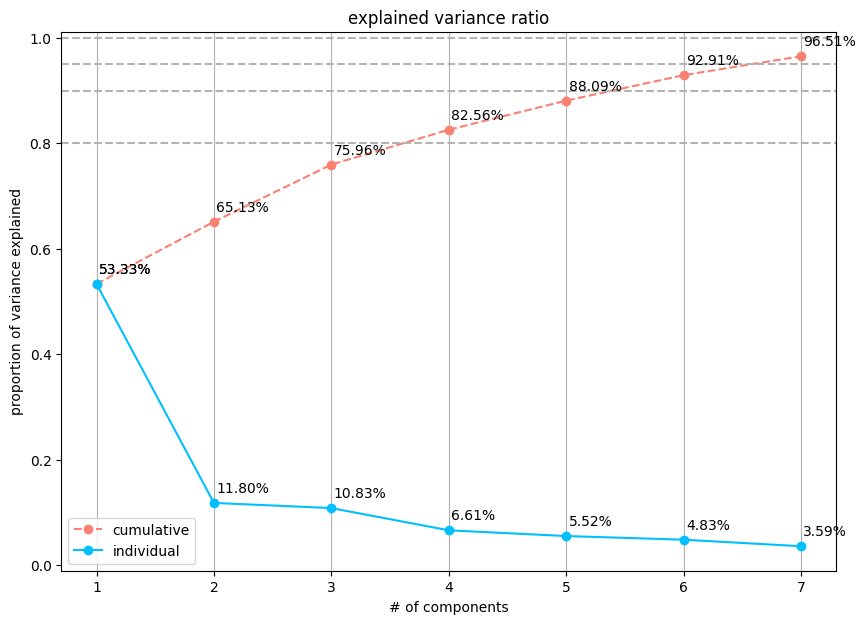

In [46]:
pca_SSTA = PCA(n_components= optimal_n_components_SSTA)

pca_SSTA.fit_transform(X_SSTAscalered)
print(f"Explained_variance (n_components = {pca_SSTA.n_components}) = {pca_SSTA.explained_variance_}") # Eigenvalues
print("-" * 100)
print(f"Explaned_variance_ratio (n_components = {pca_SSTA.n_components}) = {pca_SSTA.explained_variance_ratio_}") # Variance Ratio
print("-" * 100)
print(f"Total explained variance ratio: {np.sum(pca_SSTA.explained_variance_ratio_).round(4)}")
scree_plot(X_SSTAscalered, optimal_n_components_SSTA, True, True)

Explained_variance (n_components = 3) = [3.20691401 1.29614921 0.40520119]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 3) = [0.64127786 0.25918743 0.08102698]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9815


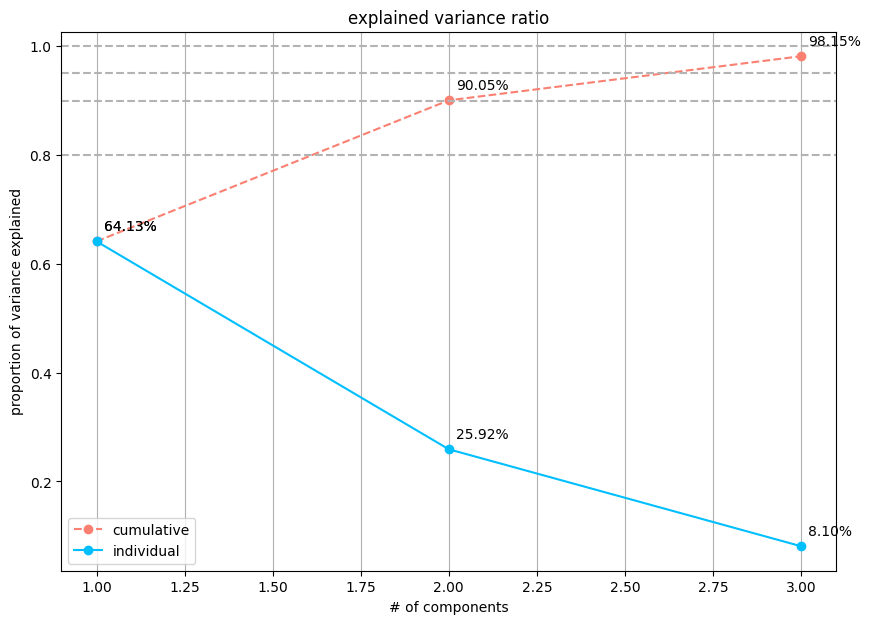

In [47]:
pca_temp = PCA(n_components= optimal_n_components_temp)

pca_temp.fit_transform(X_temperaturescalered)
print(f"Explained_variance (n_components = {pca_temp.n_components}) = {pca_temp.explained_variance_}") # Eigenvalues
print("-" * 100)
print(f"Explaned_variance_ratio (n_components = {pca_temp.n_components}) = {pca_temp.explained_variance_ratio_}") # Variance Ratio
print("-" * 100)
print(f"Total explained variance ratio: {np.sum(pca_temp.explained_variance_ratio_).round(4)}")
scree_plot(X_temperaturescalered, optimal_n_components_temp, True, True)

Explained_variance (n_components = 7) = [5.91172514 3.19792263 1.14221618 0.88287121 0.66936433 0.5333419
 0.35549625]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 7) = [0.45467369 0.2459538  0.08784841 0.06790206 0.05148114 0.04101959
 0.02734139]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9762


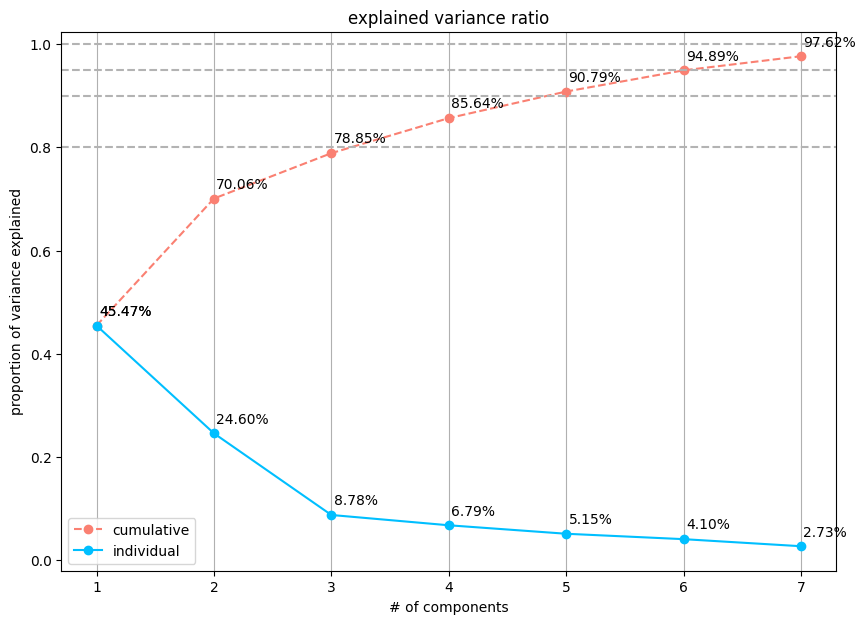

In [48]:
pca_TSA = PCA(n_components= optimal_n_components_TSA)

pca_TSA.fit_transform(X_TSAscalered)
print(f"Explained_variance (n_components = {pca_TSA.n_components}) = {pca_TSA.explained_variance_}") # Eigenvalues
print("-" * 100)
print(f"Explaned_variance_ratio (n_components = {pca_TSA.n_components}) = {pca_TSA.explained_variance_ratio_}") # Variance Ratio
print("-" * 100)
print(f"Total explained variance ratio: {np.sum(pca_TSA.explained_variance_ratio_).round(4)}")
scree_plot(X_TSAscalered, optimal_n_components_TSA, True, True)

In [49]:
dd_Other = pd.DataFrame(
    np.dot(X_Otherscalered,pca.components_.T),
    columns=[f'PC_Other{n}' for n in range(1, pca.n_components_ + 1)]
)
dd_Other.head()

,PC_Other1,PC_Other2,PC_Other3
0,-0.115980,-0.730594,0.268454
1,-0.084668,-0.445009,0.293588
2,-0.071636,-0.159032,0.337041
3,-0.104824,-0.444577,0.313787
4,-0.454570,-1.236421,-0.180481


In [50]:
dd_SSTA = pd.DataFrame(
    np.dot(X_SSTAscalered,pca_SSTA.components_.T),
    columns=[f'PC_SSTA{n}' for n in range(1, pca_SSTA.n_components_ + 1)]
)
dd_SSTA.head()

,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5,PC_SSTA6,PC_SSTA7
0,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213
1,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213
2,-0.438824,-0.335041,-1.040476,0.482801,0.638802,0.663342,-0.417204
3,-0.485837,-0.455297,-0.371020,0.751944,0.754977,0.147913,-0.119313
4,1.440056,-1.493978,-1.131518,1.181153,-0.131582,-0.013769,-1.009545


In [51]:
dd_temp = pd.DataFrame(
    np.dot(X_temperaturescalered,pca_temp.components_.T),
    columns=[f'PC_temp{n}' for n in range(1, pca_temp.n_components_ + 1)]
)
dd_temp.head()

,PC_temp1,PC_temp2,PC_temp3
0,2.373429,0.496726,-1.012526
1,2.373429,0.496726,-1.012526
2,2.150001,0.212607,-0.857113
3,2.148187,0.415116,-0.863469
4,3.186508,-0.140007,1.322067


In [52]:
dd_TSA = pd.DataFrame(
    np.dot(X_TSAscalered,pca_TSA.components_.T),
    columns=[f'PC_TSA{n}' for n in range(1, pca_TSA.n_components_ + 1)]
)
dd_TSA.head()

,PC_TSA1,PC_TSA2,PC_TSA3,PC_TSA4,PC_TSA5,PC_TSA6,PC_TSA7
0,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
1,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
2,-1.000694,1.779903,-1.016181,-0.526316,-0.192758,0.762552,0.143887
3,-0.971176,1.879708,-1.338848,-0.816011,-0.153296,0.346936,-0.030385
4,-0.527733,3.022969,0.138642,2.187186,-0.748058,-0.778868,-0.441851


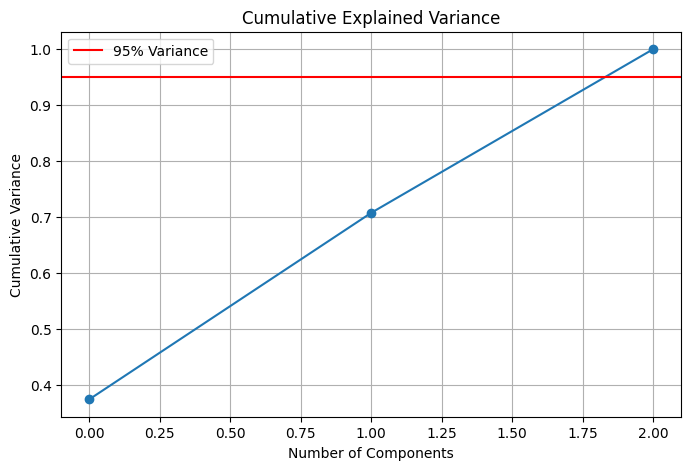

In [53]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, linestyle='-', color='red', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.grid()
plt.legend()
plt.show()

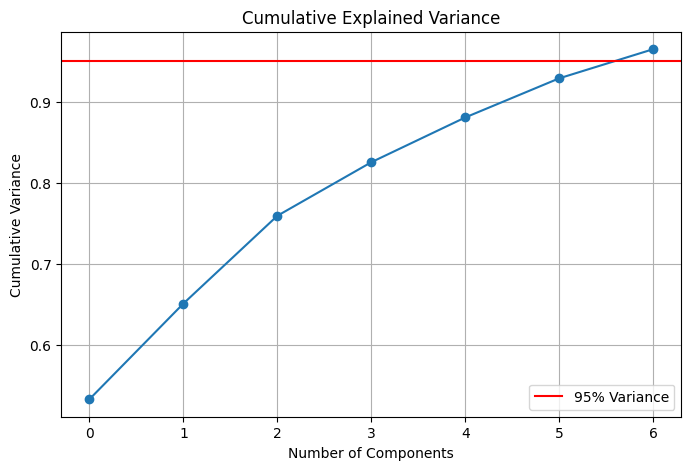

In [54]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_SSTA.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, linestyle='-', color='red', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.grid()
plt.legend()
plt.show()

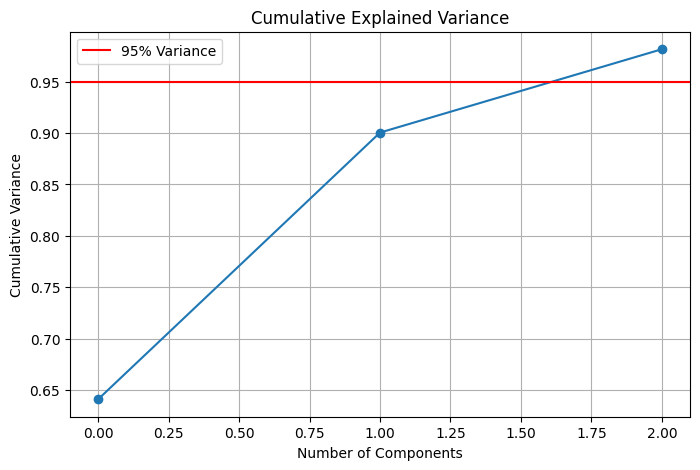

In [55]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_temp.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, linestyle='-', color='red', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.grid()
plt.legend()
plt.show()

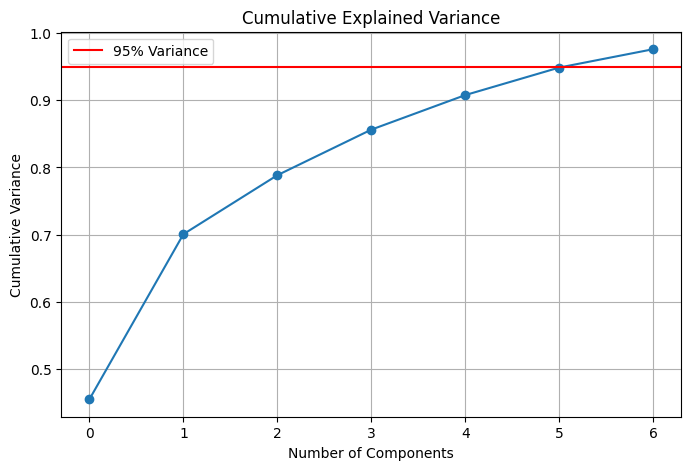

In [56]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_TSA.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, linestyle='-', color='red', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.grid()
plt.legend()
plt.show()

In [57]:
dd_allpca = pd.concat([dd_Other, dd_SSTA, dd_temp, dd_TSA], axis=1)
dd_allpca.columns = [f'PC{n}' for n in range(1, dd_allpca.shape[1] + 1)]
dd_allpca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,-0.115980,-0.730594,0.268454,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213,2.373429,0.496726,-1.012526,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
1,-0.084668,-0.445009,0.293588,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213,2.373429,0.496726,-1.012526,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
2,-0.071636,-0.159032,0.337041,-0.438824,-0.335041,-1.040476,0.482801,0.638802,0.663342,-0.417204,2.150001,0.212607,-0.857113,-1.000694,1.779903,-1.016181,-0.526316,-0.192758,0.762552,0.143887
3,-0.104824,-0.444577,0.313787,-0.485837,-0.455297,-0.371020,0.751944,0.754977,0.147913,-0.119313,2.148187,0.415116,-0.863469,-0.971176,1.879708,-1.338848,-0.816011,-0.153296,0.346936,-0.030385
4,-0.454570,-1.236421,-0.180481,1.440056,-1.493978,-1.131518,1.181153,-0.131582,-0.013769,-1.009545,3.186508,-0.140007,1.322067,-0.527733,3.022969,0.138642,2.187186,-0.748058,-0.778868,-0.441851


### ตัวแปร PCA ถูกเก็บไว้ใน dd_allpca

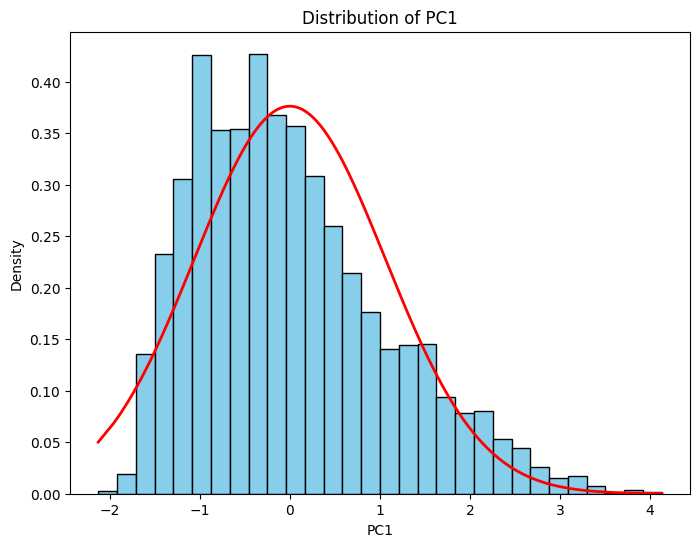

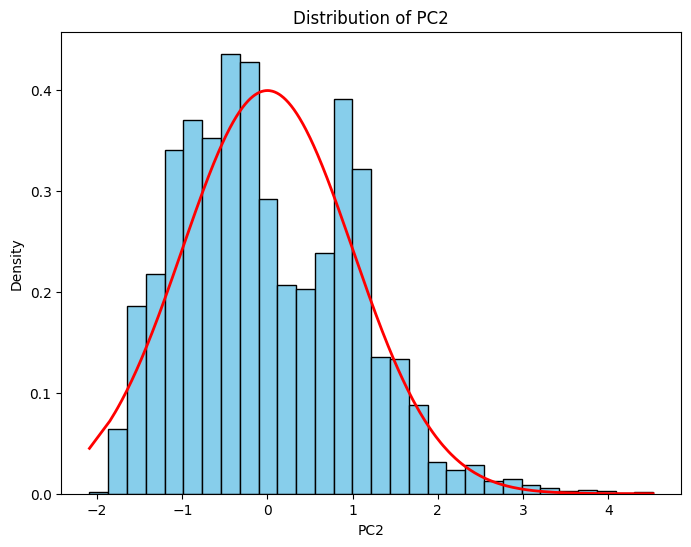

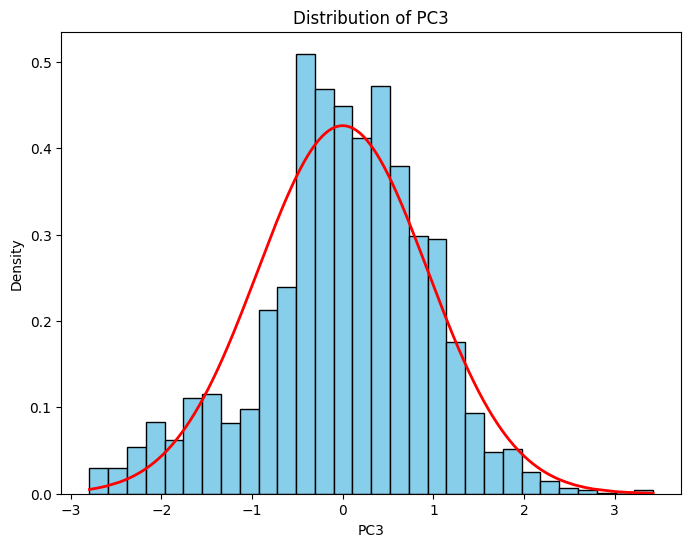

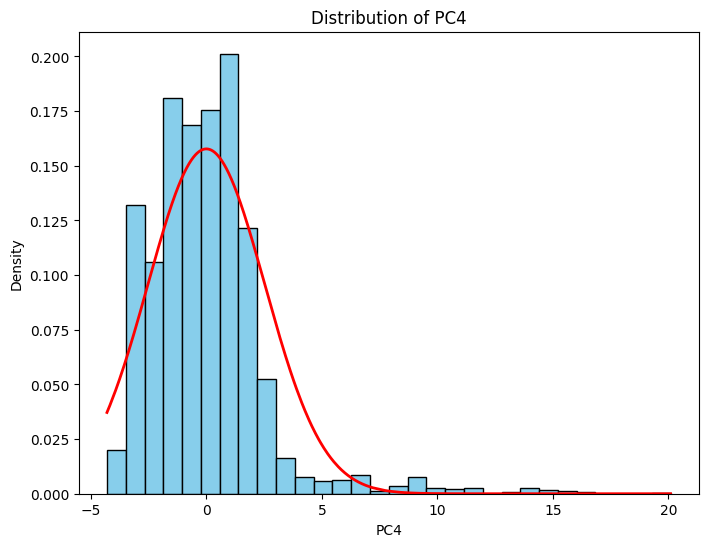

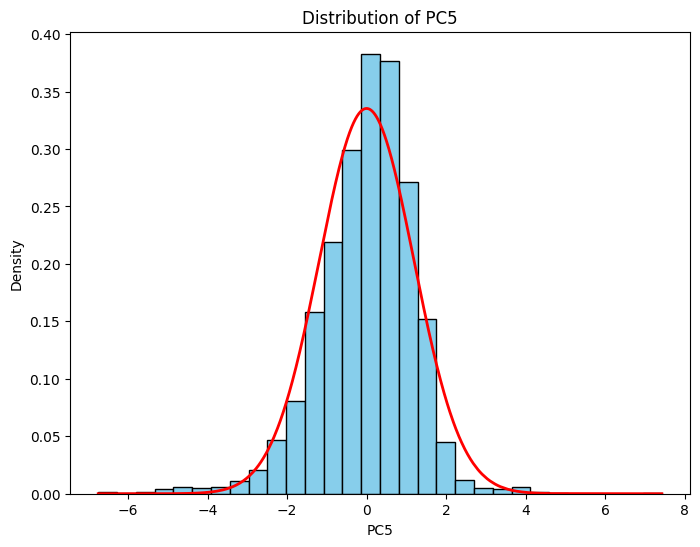

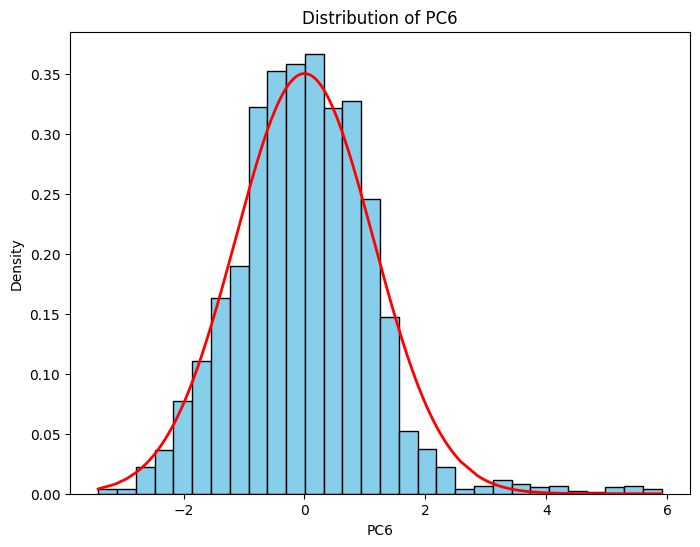

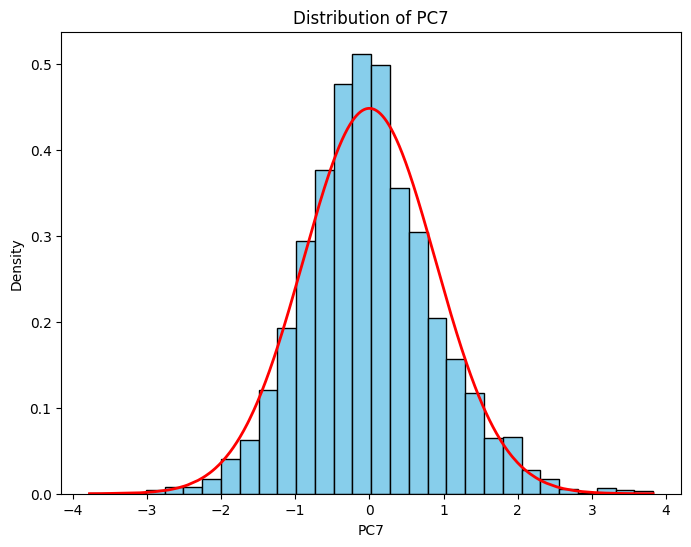

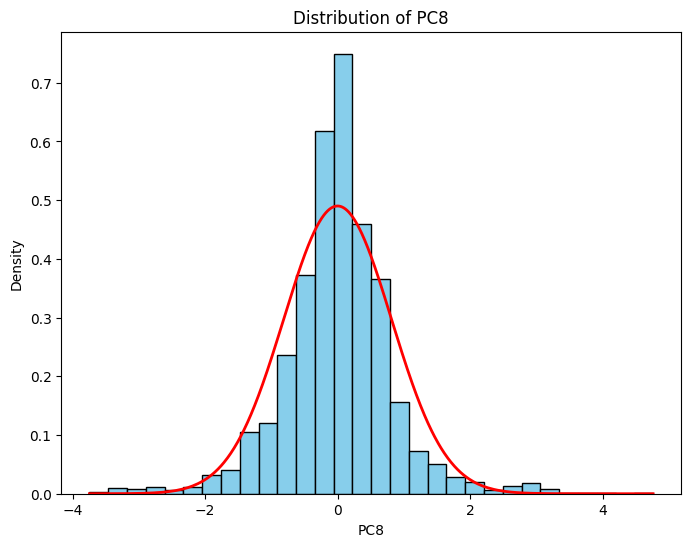

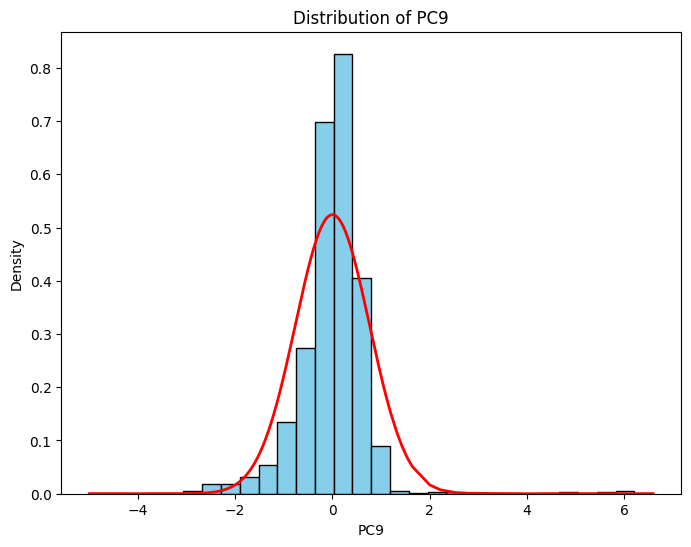

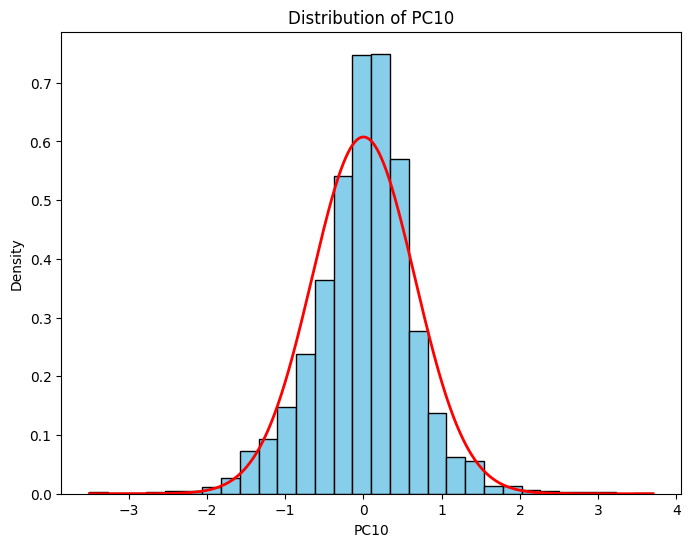

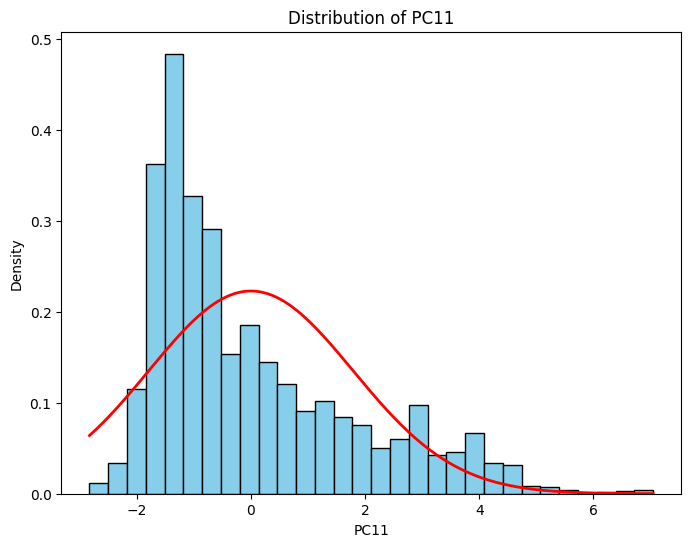

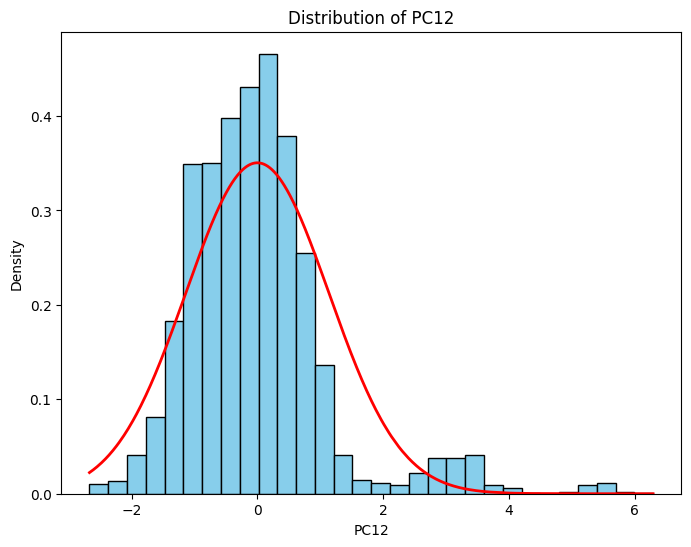

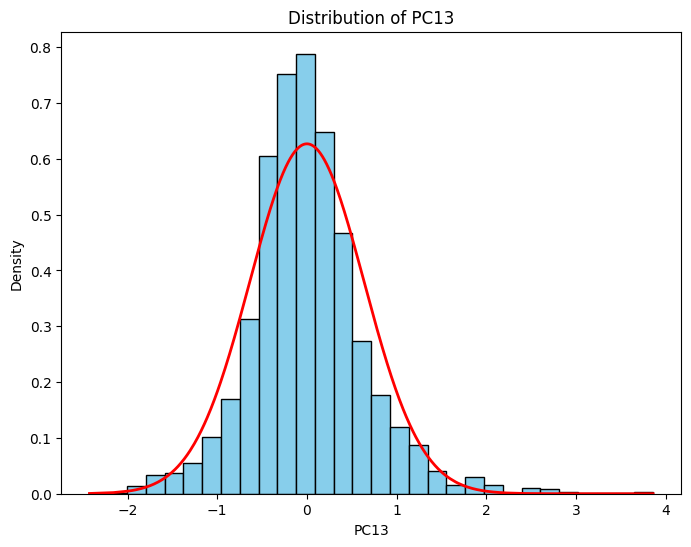

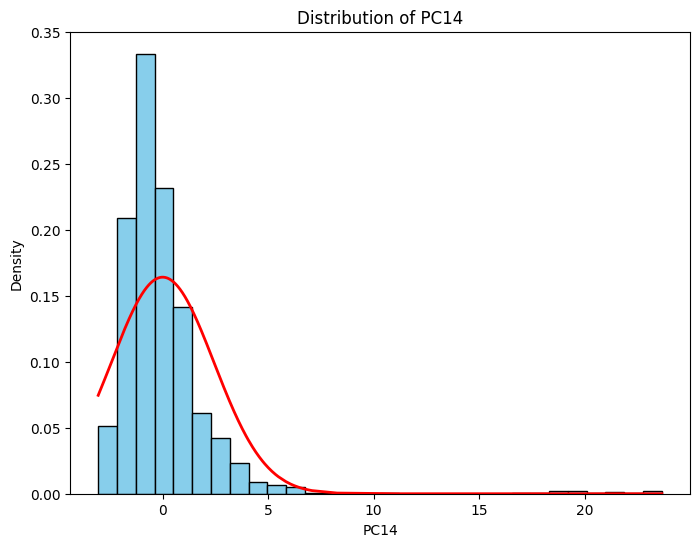

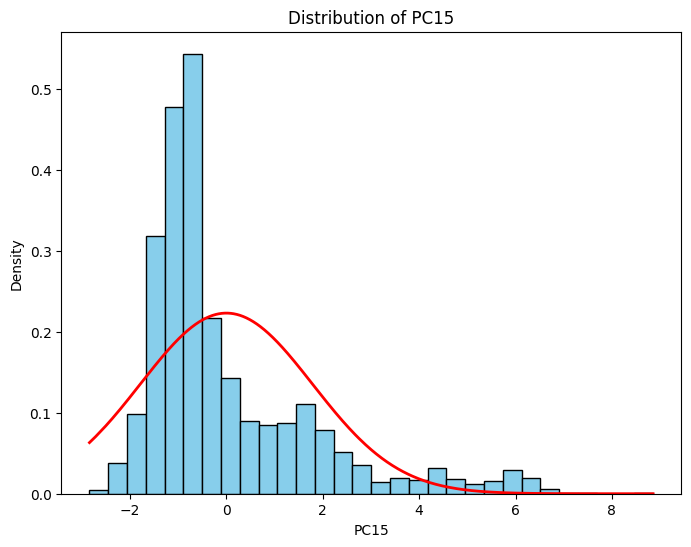

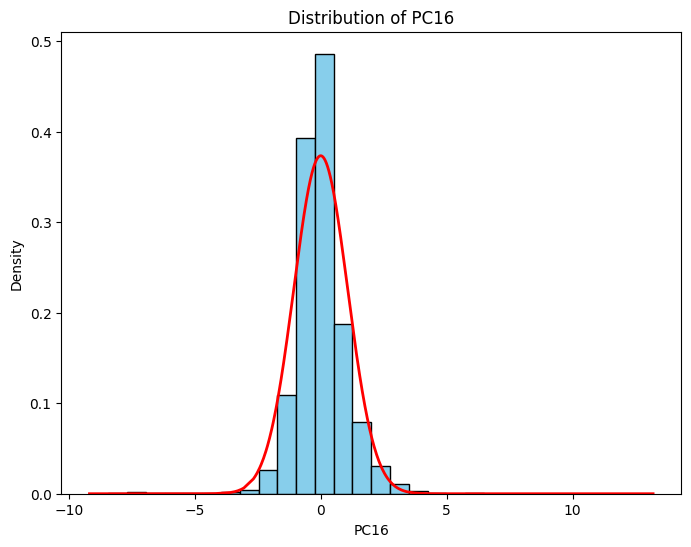

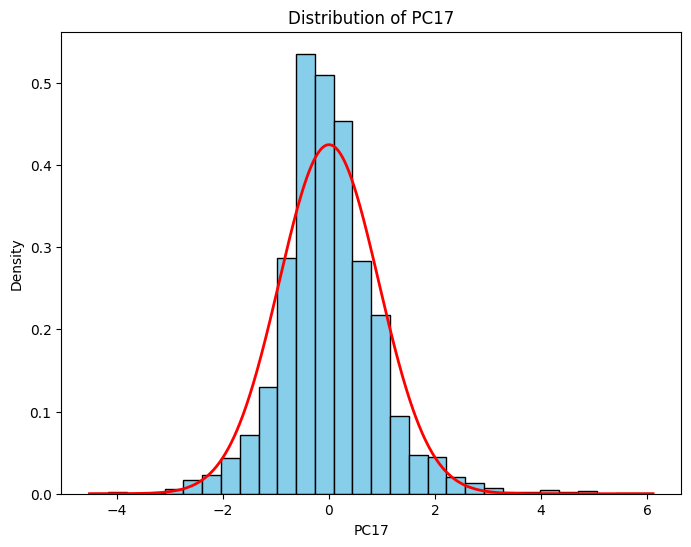

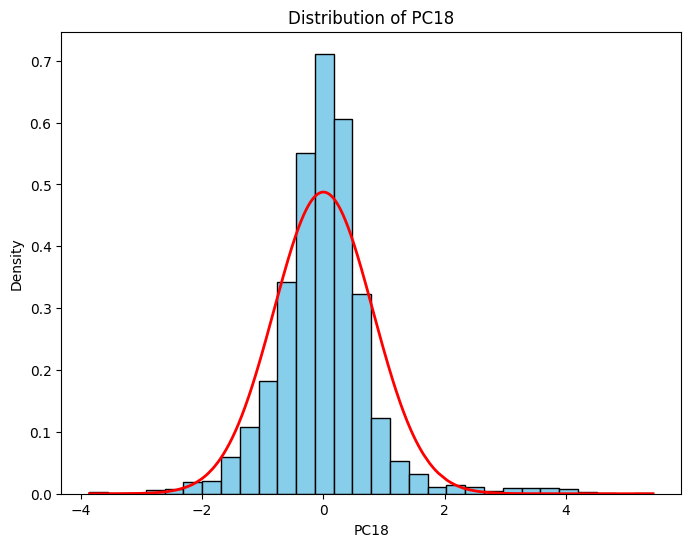

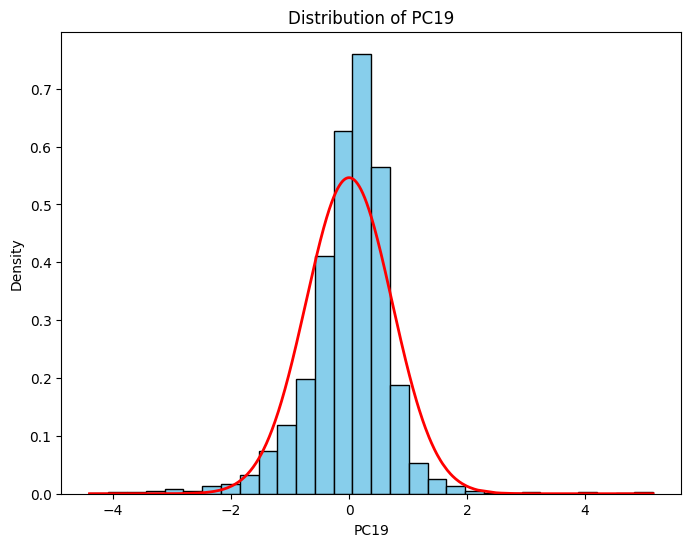

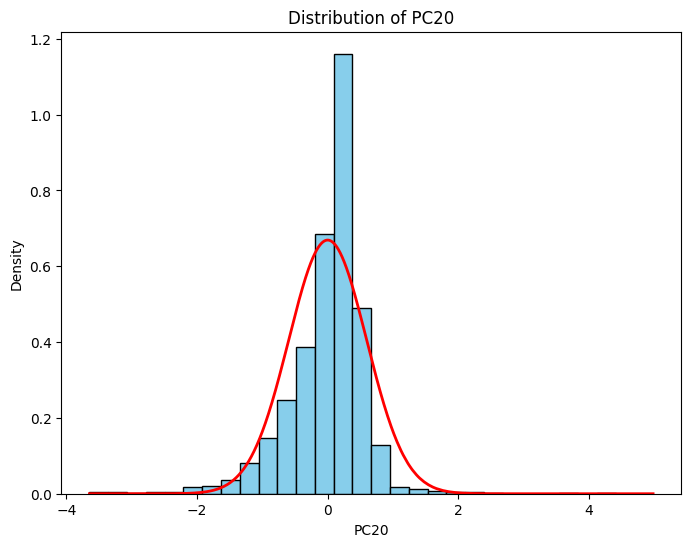

In [58]:
for i in dd_allpca.columns:
    plotting_distribution(dd_allpca , dd_allpca[[i]])

In [59]:
print(f"columns original hvae : {len(df_already_filledEXtwo.columns)} using pca of groupby have {len(dd_allpca.columns)}")

columns original hvae : 34 using pca of groupby have 20


In [60]:
feature_pca = dd_allpca
target_pca = df_already_filledEXtwo['Percent_Bleaching']

feature_pca_values = feature_pca.values
target_pca_values = target_pca.values

In [61]:
seed = 42
X_trainpca , X_testpca , y_trainpca , y_testpca = train_test_split(feature_pca_values, target_pca_values, test_size=0.2 , random_state=seed)
X_trainpca.shape , y_trainpca.shape , X_testpca.shape , y_testpca.shape

((4889, 20), (4889,), (1223, 20), (1223,))

In [62]:
rfr_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth= 16,
    max_features= 'log2',
    criterion= 'squared_error',
    bootstrap= False,
    random_state=seed,
    verbose=2
)

rfr_pca.fit(X_trainpca,y_trainpca)

building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.9s


building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82 of 300
building tree 83 of 300
building tree 84

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    7.8s


building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:   14.7s finished


RandomForestRegressor(bootstrap=False, max_depth=16, max_features='log2',
                      n_estimators=300, random_state=42, verbose=2)

In [63]:
Metric_result(rfr_pca,X_trainpca,X_testpca,y_trainpca,y_testpca)

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s


Score on training data: 0.966
------------------------------
Test MSE: 66.604
------------------------------
Test RMSE : 8.161
------------------------------
Test R2 Score : 0.227
------------------------------
Mean Absolute Error : 3.278
------------------------------
Mean Absolute Percentage Error : 5099862713067793.0
------------------------------
(1223,)
(1223,)


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


In [64]:
rfr_cross_validation_forestpca = cross_validate(rfr_pca, X_trainpca, y_trainpca, cv=5 , scoring= ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']) 

building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.5s


building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82 of 300
building tree 83 of 300
building tree 84 of 300
building tree 85

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    6.5s


building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300
building tree 202 of 300
building tree 203 of 300
building tree 204 of 300
building tree 205 of 300


...

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.5s


building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    6.4s


building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300
building tree 202 of 300
building tree 203 of 300
building tree 204 of 300
building tree 205 of 300


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:   12.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


In [65]:
RESULT_K_FOLD(rfr_cross_validation_forestpca,5)

          K-Fold Cross Validation Results (CV = 5)          
Metric     | Mean (Std)      | Scores per Fold
------------------------------------------------------------
R2         | 0.39 (±0.08)   | 0.43, 0.41, 0.22, 0.42, 0.43
RMSE       | 7.61 (±0.72)   | 7.64, 7.50, 8.95, 6.91, 7.05
MAE        | 3.13 (±0.18)   | 3.02, 3.10, 3.48, 3.00, 3.03


In [66]:
# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
xgb_modelpca = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
    learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
    subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
    colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
    random_state=seed,
    n_jobs=-1
)

# 2. เทรนโมเดล
xgb_modelpca.fit(X_trainpca, y_trainpca)

# 3. ทดสอบผล
y_pred_xgb_trainpca = xgb_modelpca.predict(X_trainpca)
y_pred_xgb_testpca = xgb_modelpca.predict(X_testpca)

print(f"Score on training data: {r2_score(y_trainpca, y_pred_xgb_trainpca):.3f}")
print("-" * 30)
print(f"Test RMSE : {mean_squared_error(y_testpca, y_pred_xgb_testpca, squared=False):.3f}")
print(f"Test R2 Score : {r2_score(y_testpca, y_pred_xgb_testpca):.3f}")
print(f"Mean Absolute Error : {mean_absolute_error(y_testpca, y_pred_xgb_testpca):.3f}")

Score on training data: 0.801
------------------------------
Test RMSE : 7.814
Test R2 Score : 0.291
Mean Absolute Error : 3.375


##

______________________

## Mean Percent model

In [67]:
y_pred_Averagemodel = df_already_filledEXtwo[['Percent_Bleaching']].mean()

def RMSE(df):
    y_true = df['Percent_Bleaching'].values
    total = 0
    
    for i in range(len(y_true)):
        error = y_true[i] - y_pred_Averagemodel
        total += error**2
    
    rmse = np.sqrt(total / len(y_true))
    return rmse

print(f"RMSE : {RMSE(df_already_filledEXtwo).round(2)}")

def R2_score(df):
    y_true = df['Percent_Bleaching'].values
    
    y_mean = np.mean(y_true)
    
    ss_res = 0  # sum of squared residuals
    ss_tot = 0  # total sum of squares
    
    for i in range(len(y_true)):
        ss_res += (y_true[i] - y_pred_Averagemodel)**2
        ss_tot += (y_true[i] - y_mean)**2
    
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"SS_res : {ss_res.round(1)}")
    print(f"SS_tot : {ss_tot.round(1)}")
    
    return r2

print(f"Percent_bleaching : {y_pred_Averagemodel}")
print("-"*50)
print(f"R2_score (rounded): {R2_score(df_already_filledEXtwo)}") # predicted less than mean so R2 is negative

RMSE : Percent_Bleaching    9.63
dtype: float64
Percent_bleaching : Percent_Bleaching    2.79522
dtype: float64
--------------------------------------------------
SS_res : Percent_Bleaching    567199.4
dtype: float64
SS_tot : 567199.4
R2_score (rounded): Percent_Bleaching    0.0
dtype: float64


##

_____________________________________

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
param_grid = {
    'n_estimators' : [100 , 200 , 300 , 400 , 500],
    'max_features' : ['sqrt', 'log2', None],
    'max_depth' : [10 , 20 ,30 , 40 , 50],
    'min_samples_split' : [2 , 5 , 10],
    'min_samples_leaf' : [1 , 2 , 3 , 4],
    'bootstrap' : [True , False],
}

rfr_Gridsearchparam = RandomForestRegressor(random_state=seed)
rfr_paramGridsearchCV = GridSearchCV(estimator=rfr_Gridsearchparam, param_grid=param_grid, cv=5, verbose=2)

# using X and y similar on experimental
rfr_paramGridsearchCV.fit(X_trainpca, y_trainpca)

rfr_paramGridsearchCV.best_params_

Metric_result(rfr_paramGridsearchCV,X_trainpca,X_testpca,y_trainpca,y_testpca)

##

##

__________________

# Artificial Neural Network (ANN)

- ใช้การ Cleaning ตาม paper เเต่ไม่ได้มีการลบ ตัวแปรที่มีความสัมนพันะ์ระหว่างกันมากออก

In [70]:
# tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense , Dropout, Input
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanSquaredError
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler , RobustScaler
from sklearn.model_selection import KFold


In [71]:
def Divide_data(df_feature, df_target, n_train):
    
    n = len(df_feature)
    n_train = n * n_train
    n_train = int(n_train)
    
    return df_feature[:n_train], df_feature[n_train:], df_target[:n_train], df_target[n_train:]

X_trainANN_pca, X_testANN_pca, y_trainANN_pca, y_testANN_pca = Divide_data(feature_pca_values, target_pca_values, 0.8)
X_trainANN_pca.shape, X_testANN_pca.shape , y_trainANN_pca.shape, y_testANN_pca.shape
    

((4889, 20), (1223, 20), (4889,), (1223,))

In [72]:
print(f"Mean : {X_trainANN_pca.mean():.4f}")   # ถ้า ≈ 0  → scaled แล้ว
print(f"Std  : {X_trainANN_pca.std():.4f}")    # ถ้า ≈ 1  → scaled แล้ว
print(f"Min  : {X_trainANN_pca.min():.4f}")
print(f"Max  : {X_trainANN_pca.max():.4f}")

Mean : -0.0115
Std  : 1.2598
Min  : -9.1822
Max  : 23.6521


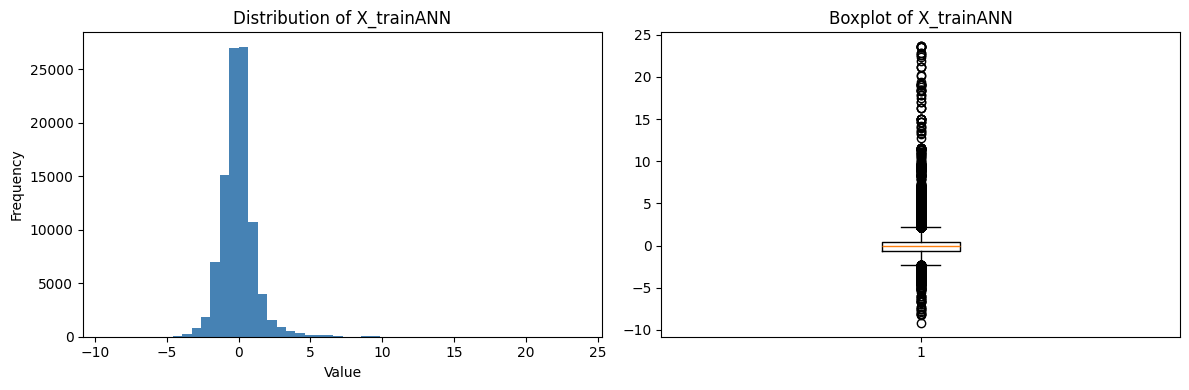

In [73]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(X_trainANN_pca.flatten(), bins=50, color='steelblue')
plt.title("Distribution of X_trainANN")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(X_trainANN_pca.flatten())
plt.title("Boxplot of X_trainANN")

plt.tight_layout()
plt.show()

In [74]:
scaler_X = RobustScaler()
scaler_y = RobustScaler()

# ✅ fit เฉพาะ train
X_trainANNpca_scaled = scaler_X.fit_transform(X_trainANN_pca)
X_testANNpca_scaled  = scaler_X.transform(X_testANN_pca)

y_trainANNpca_scaled = scaler_y.fit_transform(y_trainANN_pca.reshape(-1, 1)).flatten()
y_testANNpca_scaled  = scaler_y.transform(y_testANN_pca.reshape(-1, 1)).flatten()

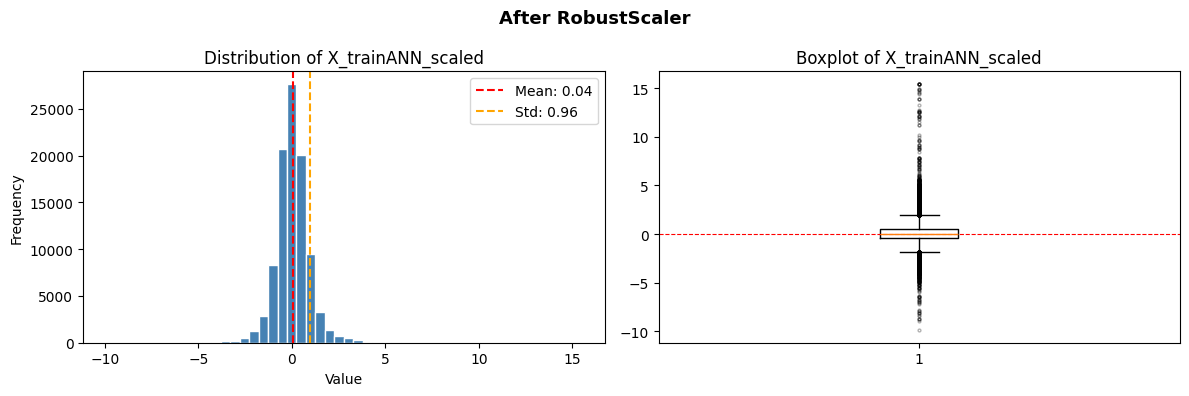

        Before vs After Scaling
                 Before      After
  Mean          -0.0115     0.0446
  Std            1.2598     0.9568
  Var            1.5870     0.9154
  Min           -9.1822    -9.8964
  Max           23.6521    15.4594


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Distribution ──────────────────────────────────
axes[0].hist(X_trainANNpca_scaled.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(X_trainANNpca_scaled.mean(), color='red',    linestyle='--', label=f'Mean: {X_trainANNpca_scaled.mean():.2f}')
axes[0].axvline(X_trainANNpca_scaled.std(),  color='orange', linestyle='--', label=f'Std: {X_trainANNpca_scaled.std():.2f}')
axes[0].set_title("Distribution of X_trainANN_scaled")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ── Boxplot ───────────────────────────────────────
axes[1].boxplot(X_trainANNpca_scaled.flatten(), 
                flierprops=dict(marker='o', markersize=2, alpha=0.3))  # ทำ outlier จางลง
axes[1].set_title("Boxplot of X_trainANN_scaled")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.suptitle("After RobustScaler", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Stats เปรียบเทียบ ─────────────────────────────
print("=" * 40)
print("        Before vs After Scaling")
print("=" * 40)
print(f"  {'':10} {'Before':>10} {'After':>10}")
print(f"  {'Mean':10} {X_trainANN_pca.mean():>10.4f} {X_trainANNpca_scaled.mean():>10.4f}")
print(f"  {'Std':10} {X_trainANN_pca.std():>10.4f} {X_trainANNpca_scaled.std():>10.4f}")
print(f"  {'Var':10} {X_trainANN_pca.var():>10.4f} {X_trainANNpca_scaled.var():>10.4f}")
print(f"  {'Min':10} {X_trainANN_pca.min():>10.4f} {X_trainANNpca_scaled.min():>10.4f}")
print(f"  {'Max':10} {X_trainANN_pca.max():>10.4f} {X_trainANNpca_scaled.max():>10.4f}")
print("=" * 40)

In [76]:
# 1. เช็ค y range ก่อน
print(f"y range: {y_trainANN_pca.min():.2f} ~ {y_trainANN_pca.max():.2f}")
print(f"y std  : {y_trainANN_pca.std():.2f}")

y range: 0.00 ~ 100.00
y std  : 9.26


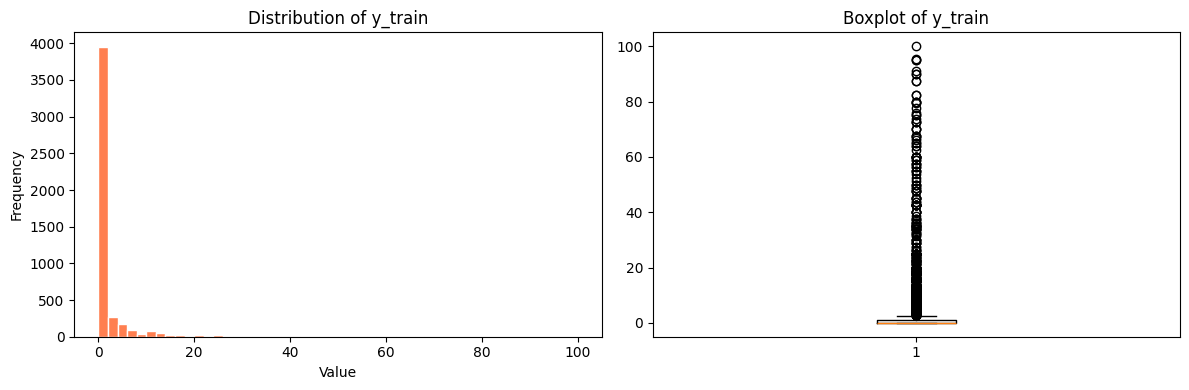

y mean   : 2.70
y median : 0.00
y std    : 9.26
y 25%    : 0.00
y 75%    : 1.00


In [77]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_trainANN_pca, bins=50, color='coral', edgecolor='white')
plt.title("Distribution of y_train")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(y_trainANN_pca)
plt.title("Boxplot of y_train")

plt.tight_layout()
plt.show()

print("="*50)
print(f"y mean   : {y_trainANN_pca.mean():.2f}")
print(f"y median : {np.median(y_trainANN_pca):.2f}")
print(f"y std    : {y_trainANN_pca.std():.2f}")
print(f"y 25%    : {np.percentile(y_trainANN_pca, 25):.2f}")
print(f"y 75%    : {np.percentile(y_trainANN_pca, 75):.2f}")
print("="*50)

#### Log transfrom y

In [78]:
# y กระจุกที่ 0 → log transform ช่วยได้มาก
y_trainANN_log = np.log1p(y_trainANN_pca)  # log(1+y) กันปัญหา log(0)
y_testANN_log  = np.log1p(y_testANN_pca)

y_trainANN_logscaled = scaler_y.fit_transform(y_trainANN_log.reshape(-1, 1)).flatten()
y_testANN_logscaled  = scaler_y.transform(y_testANN_log.reshape(-1, 1)).flatten()

In [79]:
print(f"y mean   : {y_trainANN_pca.mean():.2f}")
print(f"y median : {np.median(y_trainANN_pca):.2f}")
print(f"y = 0    : {(y_trainANN_pca == 0).sum()} samples ({(y_trainANN_pca == 0).mean()*100:.1f}%)")
print(f"y < 5    : {(y_trainANN_pca < 5).sum()} samples ({(y_trainANN_pca < 5).mean()*100:.1f}%)")
print(f"y > 50   : {(y_trainANN_pca > 50).sum()} samples ({(y_trainANN_pca > 50).mean()*100:.1f}%)")

y mean   : 2.70
y median : 0.00
y = 0    : 3120 samples (63.8%)
y < 5    : 4293 samples (87.8%)
y > 50   : 55 samples (1.1%)


In [80]:
print(f"y mean   : {y_trainANN_log.mean():.2f}")
print(f"y median : {np.median(y_trainANN_log):.2f}")
print(f"y = 0    : {(y_trainANN_log == 0).sum()} samples ({(y_trainANN_log == 0).mean()*100:.1f}%)")
print(f"y < 5    : {(y_trainANN_log < 5).sum()} samples ({(y_trainANN_log < 5).mean()*100:.1f}%)")
print(f"y > 50   : {(y_trainANN_log > 50).sum()} samples ({(y_trainANN_log > 50).mean()*100:.1f}%)")

y mean   : 0.51
y median : 0.00
y = 0    : 3120 samples (63.8%)
y < 5    : 4889 samples (100.0%)
y > 50   : 0 samples (0.0%)


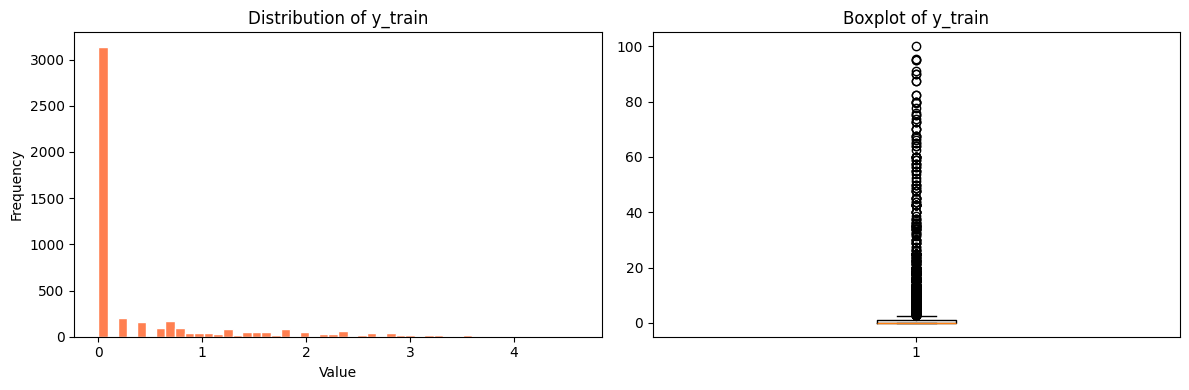

y mean   : 0.51
y median : 0.00
y std    : 0.94
y 25%    : 0.00
y 75%    : 0.69


In [81]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_trainANN_log, bins=50, color='coral', edgecolor='white')
plt.title("Distribution of y_train")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(y_trainANN_pca)
plt.title("Boxplot of y_train")

plt.tight_layout()
plt.show()

print("="*50)
print(f"y mean   : {y_trainANN_log.mean():.2f}")
print(f"y median : {np.median(y_trainANN_log):.2f}")
print(f"y std    : {y_trainANN_log.std():.2f}")
print(f"y 25%    : {np.percentile(y_trainANN_log, 25):.2f}")
print(f"y 75%    : {np.percentile(y_trainANN_log, 75):.2f}")
print("="*50)

In [82]:
def model_ANN(X_train):
        model = Sequential(
        [
            Dense(64, activation= 'relu', input_shape=(X_train.shape[1],)),
            Dropout(0.2),
            Dense(32, activation= 'relu'),
            Dense(1)
        ]
    )
        return model

model_temp = model_ANN(X_trainANN_pca)

In [83]:
model_temp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1344      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3457 (13.50 KB)
Trainable params: 3457 (13.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [84]:
model_temp.compile(
    optimizer=Adam(learning_rate=0.5),
    loss='mean_squared_error',
    metrics=[RootMeanSquaredError(), MeanAbsoluteError(), MeanSquaredError()]
    
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [85]:
def K_Fold_cross_validation(model, X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    Epoch = [8, 16, 32, 64, 128]
    Batch_size = [8, 16, 32, 64]
    fold = 1
    Error = []

    for train_idx, val_idx in kf.split(X_train):  # ✅ แก้จาก X_trainpca

        print(f"Fold {fold}")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]  # ✅ เปลี่ยนชื่อ
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        #print(X_tr.shape)
        #print(y_tr.shape)

        model.compile(
            optimizer=Adam(learning_rate=0.01),  # ✅ แก้ learning_rate
            loss='mse',
            metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
        )

        history = model.fit(
            X_tr, y_tr,                          # ✅ ใช้ X_tr แทน
            validation_data=(X_val, y_val),
            epochs=Epoch[3],
            batch_size=Batch_size[2],
            callbacks=[early_stopping],
            verbose=1
        )

        loss, rmse, mae = model.evaluate(X_val, y_val, verbose=0)
        r2 = r2_score(y_val, model.predict(X_val).flatten())

        Error.append({
            "Storage RMSE Fold": fold,           # ✅ แก้จาก fold['fold']
            "loss": loss,
            "MAE": mae,
            "RMSE Values": rmse,
            'R2' : r2,
            "history_of_loss": history.history['loss'],
            "history_of_val_loss": history.history['val_loss']
        })

        fold += 1  # ✅ เหลือแค่อันเดียว

    return Error

In [86]:
Error = K_Fold_cross_validation(model_temp,X_trainANNpca_scaled,y_trainANNpca_scaled)

Fold 1
Epoch 1/64

123/123 [==============================] - 1s 3ms/step - loss: 82.6779 - root_mean_squared_error: 9.0927 - mean_absolute_error: 3.8437 - val_loss: 65.0082 - val_root_mean_squared_error: 8.0628 - val_mean_absolute_error: 3.2086
Epoch 2/64
123/123 [==============================] - 0s 2ms/step - loss: 79.5097 - root_mean_squared_error: 8.9168 - mean_absolute_error: 3.6940 - val_loss: 62.7408 - val_root_mean_squared_error: 7.9209 - val_mean_absolute_error: 3.4146
Epoch 3/64
123/123 [==============================] - 0s 2ms/step - loss: 73.2650 - root_mean_squared_error: 8.5595 - mean_absolute_error: 3.6301 - val_loss: 64.1398 - val_root_mean_squared_error: 8.0087 - val_mean_absolute_error: 2.9570
Epoch 4/64
123/123 [==============================] - 0s 2ms/step - loss: 74.8009 - root_mean_squared_error: 8.6488 - mean_absolute_error: 3.6212 - val_loss: 59.2584 - val_root_mean_squared_error: 7.6979 - val_mean_absolute_error: 3.1111
Epoch 5/64
123/123 [====================

In [87]:
def evaluate_model(model, X_test, y_test, scaler_y=None): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    if scaler_y is not None:
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)

    return {
        "MSE"  : mse,
        "RMSE" : rmse,
        "MAE"  : mae,
        "MAPE" : mape,
        "R2"   : r2,
        "y_pred" : y_pred,  # ← เก็บไว้ plot ด้วย
        "y_test" : y_test
    }


         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 53.072464 7.285085 2.974914 0.258490
    2 39.788883 6.307843 2.771042 0.568772
    3 59.538097 7.716094 2.966313 0.477772
    4 21.226261 4.607197 2.224340 0.645849
    5 31.089190 5.575768 2.596347 0.654529
  Mean  Loss : 40.9430
  Std   Loss : 15.6531
------------------------------
  Mean  RMSE : 6.2984
  Std   RMSE : 1.2615
------------------------------
  Mean  MAE  : 2.7066
  Std   MAE  : 0.3116
------------------------------
  Mean  R2   : 0.5211
  Std   R2   : 0.1632


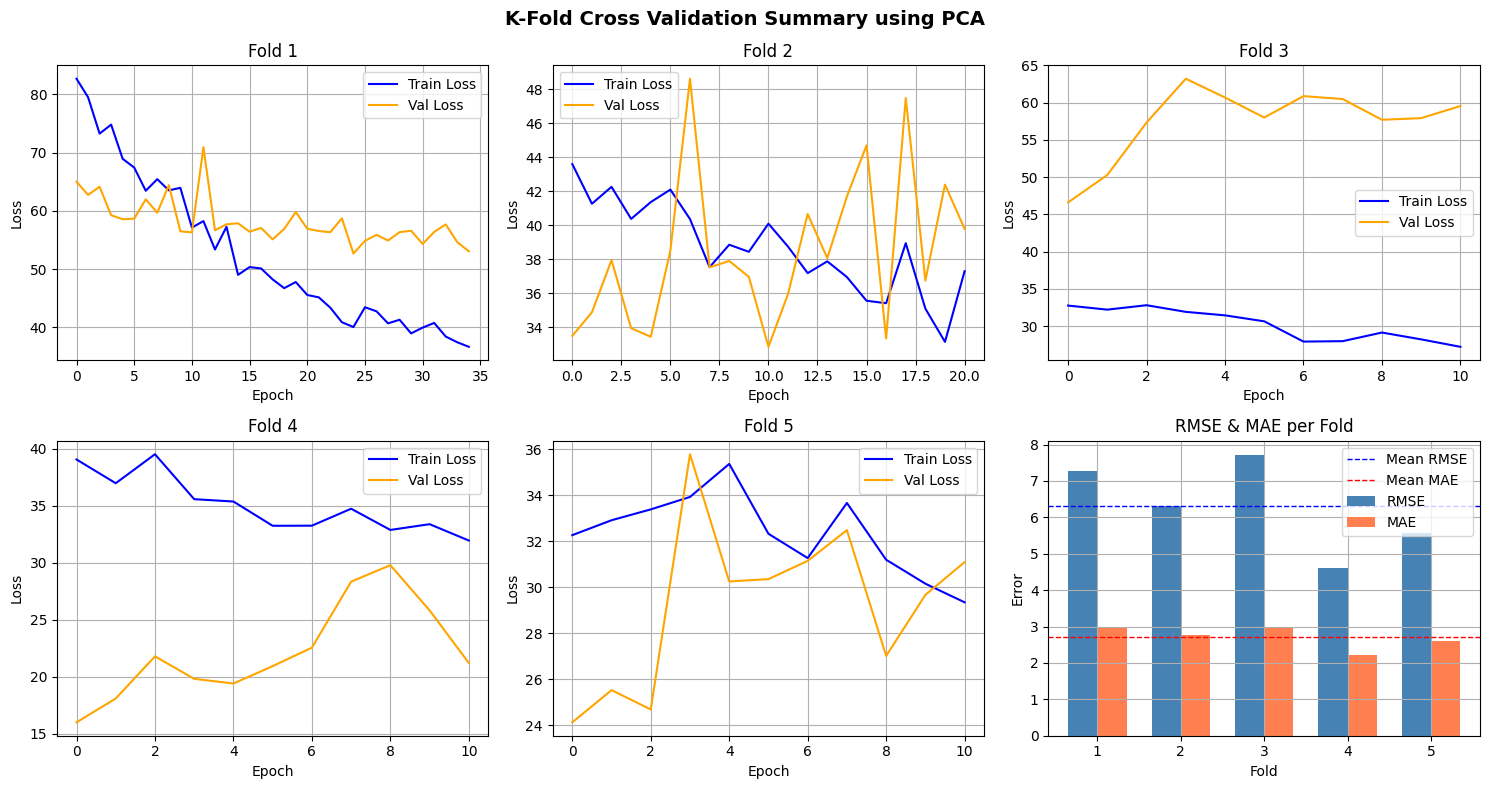

In [88]:
def show_kfold_results(Error):
    
    # ── 1. สรุปตาราง ──────────────────────────────────────────
    df_results = pd.DataFrame([{
        "Fold"  : e["Storage RMSE Fold"],
        "Loss"  : e["loss"],
        "RMSE"  : e["RMSE Values"],
        "MAE"   : e["MAE"],
        "R2"    : e["R2"]
    } for e in Error])
    
    print("=" * 50)
    print("         K-Fold Cross Validation Results")
    print("=" * 50)
    print(df_results.to_string(index=False))
    print("=" * 50)
    print(f"  Mean  Loss : {df_results['Loss'].mean():.4f}")
    print(f"  Std   Loss : {df_results['Loss'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  RMSE : {df_results['RMSE'].mean():.4f}")
    print(f"  Std   RMSE : {df_results['RMSE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  MAE  : {df_results['MAE'].mean():.4f}")
    print(f"  Std   MAE  : {df_results['MAE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  R2   : {df_results['R2'].mean():.4f}")
    print(f"  Std   R2   : {df_results['R2'].std():.4f}")
    print("=" * 50)
    
    # ── 2. Plot Loss curve แต่ละ Fold ─────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, e in enumerate(Error):
        ax = axes[i]
        ax.plot(e["history_of_loss"],     label="Train Loss", color="blue")
        ax.plot(e["history_of_val_loss"], label="Val Loss",   color="orange")
        ax.set_title(f"Fold {e['Storage RMSE Fold']}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)
    
    # ── slot สุดท้าย → สรุป RMSE/MAE ทุก fold ────────────────
    ax = axes[len(Error)]
    x = df_results["Fold"]
    width = 0.35
    ax.bar(x - width/2, df_results["RMSE"], width, label="RMSE", color="steelblue")
    ax.bar(x + width/2, df_results["MAE"],  width, label="MAE",  color="coral")
    ax.axhline(df_results["RMSE"].mean(), color="blue",   linestyle="--", linewidth=1, label="Mean RMSE")
    ax.axhline(df_results["MAE"].mean(),  color="red",    linestyle="--", linewidth=1, label="Mean MAE")
    ax.set_title("RMSE & MAE per Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_xticks(x)
    ax.legend()
    ax.grid(True)
    
    plt.suptitle("K-Fold Cross Validation Summary using PCA", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_results

# เรียกใช้
df_results = show_kfold_results(Error)

39/39 [==============================] - 0s 869us/step


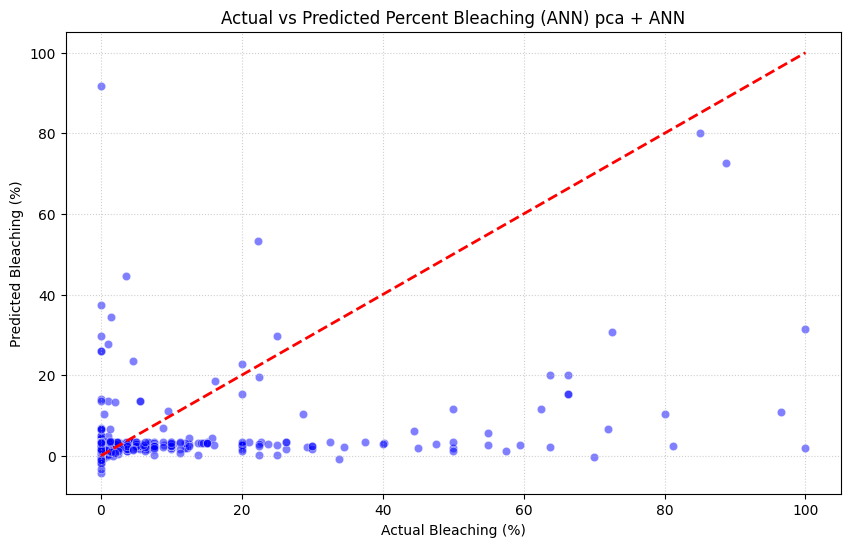

In [89]:
# Predict
y_pred_ANNpca_train = model_temp.predict(X_trainANNpca_scaled)
y_pred_ANNpca_test = model_temp.predict(X_testANNpca_scaled)
y_pred_ANNpca_testtransform = scaler_y.transform(y_pred_ANNpca_test)

# แปลงเป็น 1D
y_pred_ANNpca_testtransform = y_pred_ANNpca_testtransform.ravel()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_testANNpca_scaled,
    y=y_pred_ANNpca_testtransform,
    alpha=0.5,
    color='blue'
)

# เส้น ideal line
plt.plot(
    [y_testANNpca_scaled.min(), y_testANNpca_scaled.max()],
    [y_testANNpca_scaled.min(), y_testANNpca_scaled.max()],
    color='red',
    linestyle='--',
    lw=2
)

plt.title('Actual vs Predicted Percent Bleaching (ANN) pca + ANN')
plt.xlabel('Actual Bleaching (%)')
plt.ylabel('Predicted Bleaching (%)')

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [90]:
def evaluate_model(model, X_test, y_test, scaler_y=None): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    if scaler_y is not None:
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)

In [91]:
evaluate_model(model_temp, X_testANNpca_scaled , y_testANNpca_scaled, scaler_y)

39/39 [==============================] - 0s 909us/step
        Model Performance (Real Scale)
  MSE  : 50.9934
  RMSE : 7.1410
  MAE  : 2.6742
  R²   : 0.1240


## Log transfrom y(target)

In [92]:
Error_log_tranform = K_Fold_cross_validation(model_temp,X_trainANNpca_scaled,y_trainANN_logscaled)

Fold 1
Epoch 1/64
123/123 [==============================] - 1s 3ms/step - loss: 9.5340 - root_mean_squared_error: 3.0877 - mean_absolute_error: 1.2814 - val_loss: 1.7326 - val_root_mean_squared_error: 1.3163 - val_mean_absolute_error: 0.9740
Epoch 2/64
123/123 [==============================] - 0s 2ms/step - loss: 2.0125 - root_mean_squared_error: 1.4186 - mean_absolute_error: 0.9574 - val_loss: 1.5980 - val_root_mean_squared_error: 1.2641 - val_mean_absolute_error: 1.0355
Epoch 3/64
123/123 [==============================] - 0s 2ms/step - loss: 1.6446 - root_mean_squared_error: 1.2824 - mean_absolute_error: 0.9293 - val_loss: 1.4624 - val_root_mean_squared_error: 1.2093 - val_mean_absolute_error: 0.9095
Epoch 4/64
123/123 [==============================] - 0s 2ms/step - loss: 1.5754 - root_mean_squared_error: 1.2551 - mean_absolute_error: 0.9022 - val_loss: 1.5138 - val_root_mean_squared_error: 1.2304 - val_mean_absolute_error: 1.0035
Epoch 5/64
123/123 [=============================

         K-Fold Cross Validation Results
 Fold     Loss     RMSE      MAE       R2
    1 1.321351 1.149500 0.848184 0.273825
    2 1.181604 1.087016 0.813013 0.359689
    3 1.267254 1.125724 0.777614 0.379027
    4 0.963722 0.981693 0.691472 0.388365
    5 1.136874 1.066243 0.777195 0.387194
  Mean  Loss : 1.1742
  Std   Loss : 0.1379
------------------------------
  Mean  RMSE : 1.0820
  Std   RMSE : 0.0648
------------------------------
  Mean  MAE  : 0.7815
  Std   MAE  : 0.0583
------------------------------
  Mean  R2   : 0.3576
  Std   R2   : 0.0482


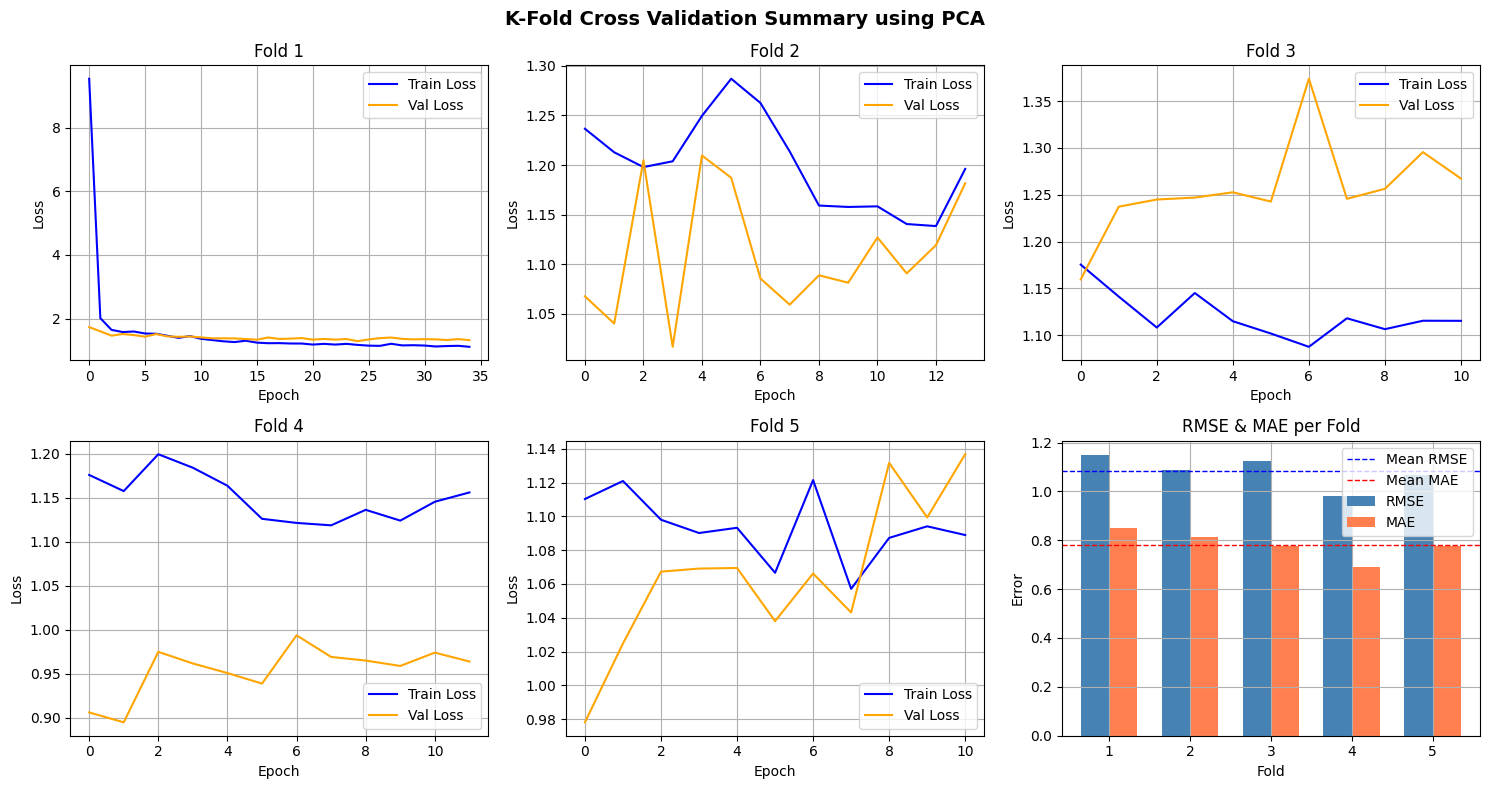

In [93]:
df_results = show_kfold_results(Error_log_tranform)

## all feature

In [94]:
feature_exANN = df_already_filledEXtwo.drop(columns=['Percent_Bleaching'])
target_exANN = df_already_filledEXtwo[['Percent_Bleaching']]

feature_exANN_values = feature_exANN.values
target_exANN_values = target_exANN.values

In [95]:
def Divide_data(df_feature, df_target, n_train):
    
    n = len(df_feature)
    n_train = n * n_train
    n_train = int(n_train)
    
    return df_feature[:n_train], df_feature[n_train:], df_target[:n_train], df_target[n_train:]

X_trainANNnonpca, X_testANNnonpca, y_trainANNnonpca, y_testANNnonpca = Divide_data(feature_exANN_values, target_exANN_values, 0.8)
X_trainANNnonpca.shape, X_testANNnonpca.shape , y_trainANNnonpca.shape, y_testANNnonpca.shape
    

((4889, 33), (1223, 33), (4889, 1), (1223, 1))

In [96]:
# ✅ fit เฉพาะ train
X_trainANNnonpca_scaled = scaler_X.fit_transform(X_trainANNnonpca)
X_testANNnonpca_scaled  = scaler_X.transform(X_testANNnonpca)

y_trainANNnonpca_scaled = scaler_y.fit_transform(y_trainANNnonpca.reshape(-1, 1)).flatten()
y_testANNnonpca_scaled  = scaler_y.transform(y_testANNnonpca.reshape(-1, 1)).flatten()

#### สรุป : ไม่ว่าจะเพิ่ม Layer หรือทำให้ parameter เพิ่มขึ้นเเค่ไหนก็ไม่ได้ช่วยโมเดลขึ้นเพราะ  zero-inflation มีจำนวนถึง 63.9% ดังนั้นต้องเเก้ปัญหาตรงนี้

In [97]:
model_nondatapca = Sequential([
            Dense(256, activation='relu', input_shape=(X_testANNnonpca_scaled.shape[1],)),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.2),
            Dense(64,  activation='relu'),
            Dense(1)
        ]        
    )

In [98]:
model_nondatapca.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 256)               8704      
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 1)                 65        
                                                                 
Total params: 49921 (195.00 KB)
Trainable params: 4992

In [99]:
Errordatanonpca = K_Fold_cross_validation(model_nondatapca,X_trainANNnonpca_scaled,y_trainANNnonpca_scaled)

Fold 1
Epoch 1/64
123/123 [==============================] - 1s 4ms/step - loss: 84.8181 - root_mean_squared_error: 9.2097 - mean_absolute_error: 3.7440 - val_loss: 71.3874 - val_root_mean_squared_error: 8.4491 - val_mean_absolute_error: 4.7034
Epoch 2/64
123/123 [==============================] - 0s 2ms/step - loss: 81.1477 - root_mean_squared_error: 9.0082 - mean_absolute_error: 3.7500 - val_loss: 72.2771 - val_root_mean_squared_error: 8.5016 - val_mean_absolute_error: 3.9675
Epoch 3/64
123/123 [==============================] - 0s 2ms/step - loss: 77.8964 - root_mean_squared_error: 8.8259 - mean_absolute_error: 3.4830 - val_loss: 68.1522 - val_root_mean_squared_error: 8.2554 - val_mean_absolute_error: 2.9961
Epoch 4/64
123/123 [==============================] - 0s 2ms/step - loss: 74.5675 - root_mean_squared_error: 8.6352 - mean_absolute_error: 3.5082 - val_loss: 60.7583 - val_root_mean_squared_error: 7.7948 - val_mean_absolute_error: 3.1296
Epoch 5/64
123/123 [=====================

         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 58.112331 7.623145 3.485678 0.188075
    2 51.016094 7.142555 3.346798 0.447092
    3 80.508736 8.972666 3.712646 0.293832
    4 39.471657 6.282647 3.064462 0.341432
    5 50.085106 7.077083 3.327590 0.443441
  Mean  Loss : 55.8388
  Std   Loss : 15.3136
------------------------------
  Mean  RMSE : 7.4196
  Std   RMSE : 0.9925
------------------------------
  Mean  MAE  : 3.3874
  Std   MAE  : 0.2371
------------------------------
  Mean  R2   : 0.3428
  Std   R2   : 0.1088


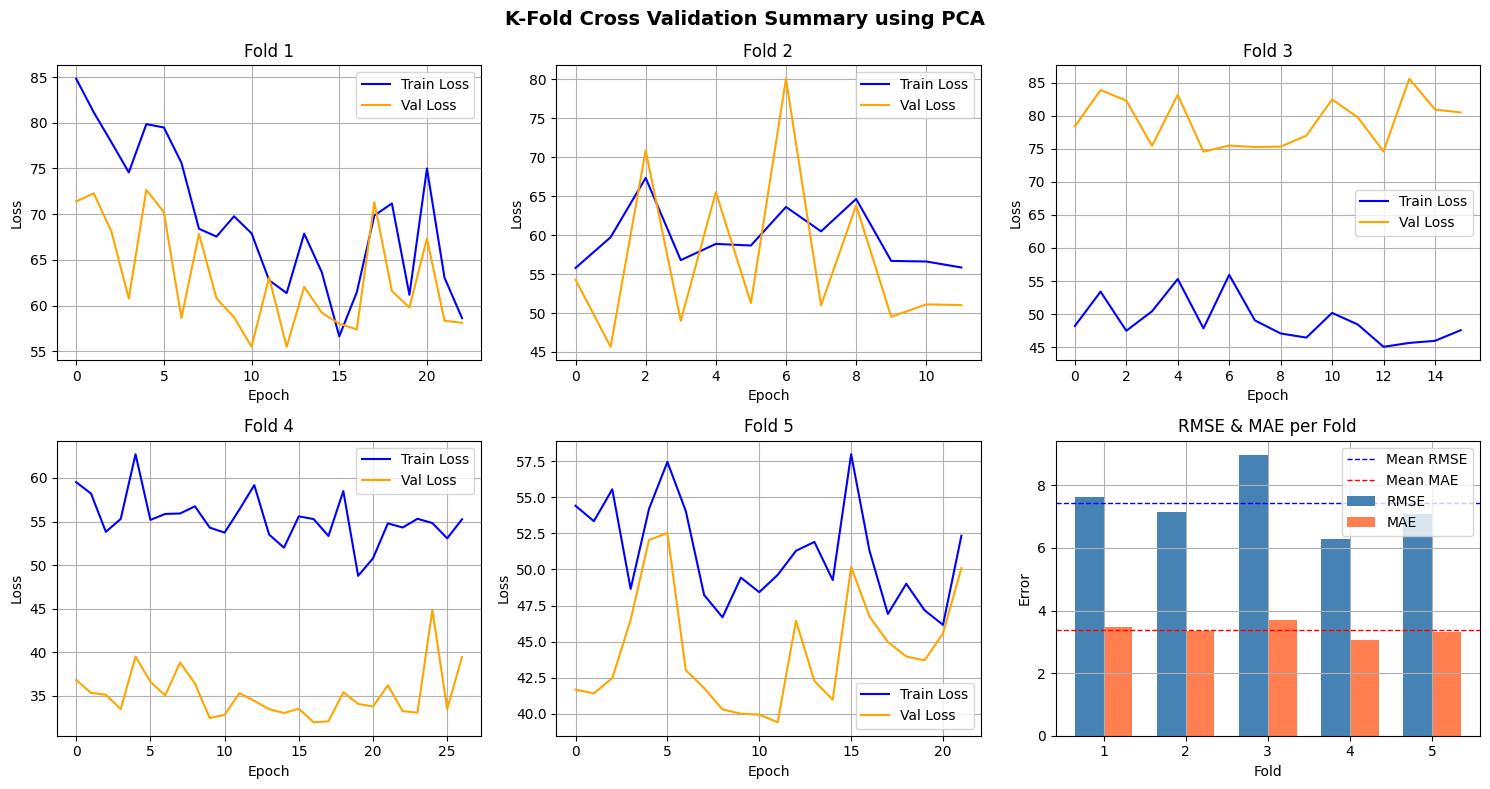

In [100]:
df_results = show_kfold_results(Errordatanonpca)

____________________________

## Feature Engineer  Experimental

In [101]:
df_Future_engineer = df_already_filledEXtwo.copy()

In [102]:
df_already_filledEXtwo[['Depth_m']].describe()

,Depth_m
count,6112.000000
mean,6.471188
std,3.467763
min,0.100000
25%,4.000000
50%,6.000000
75%,10.000000
max,23.000000


In [103]:
# โอกาสเกิด ปะการังฟอกขาวต่ำ เพราะโดนเเสงน้อย
df_already_filledEXtwo[
    (df_already_filledEXtwo['Depth_m'] > 10) & 
    (df_already_filledEXtwo['Depth_m'] <= 23)
].describe()

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
count,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,...,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000
mean,12.683358,3.402603,294.922135,302.003382,300.981051,296.882530,304.986167,1.322992,4.729013,0.699564,...,2.601427,-1.384839,2.401382,1.811728,8.316863,1.021814,1.124534,1.312066,9.851350,0.523851
std,2.009191,9.625054,14.717678,1.724314,1.209361,1.548303,1.086743,0.382989,2.174585,0.520594,...,0.687113,0.638350,2.587843,0.741941,3.885673,1.322792,2.150357,0.761294,4.089445,0.622479
min,10.100000,0.000000,262.150000,295.540000,296.290000,285.260000,301.640000,0.830000,0.000000,0.010000,...,1.630000,-5.070000,0.000000,0.680000,3.000000,0.000000,0.000000,0.490000,2.590000,0.130000
25%,11.500000,0.000000,299.390000,300.876250,300.230000,296.440000,304.293750,1.140000,3.000000,0.300000,...,2.270000,-1.500000,0.000000,1.317000,6.000000,0.000000,0.000000,0.930000,7.275000,0.270000
50%,12.000000,0.000000,301.440000,302.170000,301.100000,297.250000,305.040000,1.220000,5.000000,0.600000,...,2.460000,-1.380000,2.000000,1.550000,7.000000,1.000000,0.000000,1.110000,9.180000,0.380000
75%,13.000000,2.500000,302.400000,303.310000,301.860000,297.770000,305.600000,1.400000,6.000000,1.003000,...,2.825000,-0.870000,4.000000,2.280000,10.000000,2.000000,1.350000,1.550000,11.520000,0.680000
max,23.000000,100.000000,304.110000,305.260000,303.520000,299.830000,311.010000,4.210000,12.000000,2.930000,...,8.553333,-0.130000,21.000000,5.490000,38.000000,20.000000,20.620000,12.260000,46.340000,11.620000


In [104]:
# โอกาสเกิด ปะการังฟอกขาวสูง เพราะโดนเเสงเต็มๆ
df_already_filledEXtwo[
    (df_already_filledEXtwo['Depth_m'] > 3) & 
    (df_already_filledEXtwo['Depth_m'] <= 10)
].describe()

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
count,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,...,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000
mean,6.810435,2.784361,293.643438,301.682768,300.541405,295.954913,305.153165,1.624873,4.462121,0.715804,...,2.795596,-1.797722,2.302500,1.909876,8.736079,1.188605,1.151233,1.493614,10.996765,0.608117
std,2.202804,9.930362,15.305921,2.143169,1.766711,2.701283,1.476025,0.694600,2.117608,0.556305,...,0.911028,1.033599,2.999956,0.724927,4.212985,1.918135,3.077394,1.202768,5.398598,1.077886
min,3.100000,0.000000,262.150000,292.820000,294.300000,284.540000,301.430000,0.800000,0.000000,0.007500,...,1.370000,-7.460000,0.000000,0.680000,3.000000,0.000000,0.000000,0.480000,3.410000,0.110000
25%,5.000000,0.000000,297.635000,300.568304,299.650000,294.345000,304.440000,1.180000,3.000000,0.290000,...,2.300000,-2.416667,0.000000,1.390000,6.000000,1.000000,0.000000,1.010000,7.650000,0.330000
50%,6.000000,0.000000,300.940000,302.237500,301.120000,297.010000,305.270000,1.340000,4.000000,0.600000,...,2.600000,-1.440000,1.250000,1.760000,8.000000,1.000000,0.000000,1.290000,9.690000,0.440000
75%,9.000000,1.000000,302.250000,303.148125,301.840000,297.830000,305.887500,2.040000,6.000000,1.000000,...,3.026250,-1.177500,3.000000,2.260000,10.000000,1.000000,1.160000,1.712500,12.850000,0.630000
max,10.000000,100.000000,304.390000,306.800000,303.340000,299.880000,313.140000,5.820000,14.000000,4.610000,...,10.220000,0.000000,25.000000,6.910000,38.000000,20.000000,37.680000,13.930000,49.240000,12.660000


In [105]:
def classify_depth(depth):
    if depth <= 3: return 'Intertidal'
    elif depth <= 10: return 'Shallow'
    elif depth <= 25: return 'Intermediate'
    else: return 'Deep_Refugia'

df_Future_engineer['Depth_Class'] = df_Future_engineer['Depth_m'].apply(classify_depth)

In [106]:

df_Future_engineer[['SSTA_DHW']].describe()

,SSTA_DHW
count,6112.000000
mean,3.153033
std,4.082572
min,0.000000
25%,0.000000
50%,1.918750
75%,4.602500
max,38.450000


In [107]:
df_Future_engineer

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Depth_Class
0,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,Shallow
1,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,Shallow
2,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,5.0,0.870000,...,-3.060,1.0,1.470,5.000000,1.0,1.51,1.230000,7.32,0.490000,Shallow
3,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,5.0,1.070000,...,-3.010,2.0,1.310,5.000000,1.0,2.36,0.970000,6.86,0.360000,Shallow
4,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,4.0,1.760000,...,-3.230,4.0,1.720,7.000000,1.0,0.00,1.470000,9.84,0.560000,Intertidal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9641,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,4.0,0.033333,...,-5.255,0.0,1.645,7.333333,1.0,0.00,1.381667,11.57,0.446667,Shallow
9646,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,3.0,0.510000,...,-5.080,0.0,2.180,11.000000,1.0,0.00,1.740000,12.00,0.640000,Intertidal
9649,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,4.0,0.050000,...,-3.240,0.0,1.400,6.000000,0.0,0.00,1.710000,19.41,0.370000,Shallow
9663,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,6.0,0.110000,...,-2.690,0.0,1.630,6.000000,1.0,0.00,1.330000,8.30,0.540000,Shallow


In [108]:
# 1. ล้าง Index ของ DataFrame หลักก่อน
df_Future_engineer = df_Future_engineer.reset_index(drop=True)

# 2. สร้าง dummy และล้าง Index ของ dummy ทันที
depth_encoded = pd.get_dummies(df_Future_engineer['Depth_Class'], prefix='Depth').reset_index(drop=True)

# 3. รวมเข้าด้วยกัน
df_Future_engineer = pd.concat([df_Future_engineer, depth_encoded], axis=1)

# 4. เปลี่ยน True/False เป็น 1/0
cols_to_fix = ['Depth_Intertidal', 'Depth_Shallow', 'Depth_Intermediate']
# ตรวจสอบว่าคอลัมน์มีครบไหมก่อนเปลี่ยน
df_Future_engineer[cols_to_fix] = df_Future_engineer[cols_to_fix].astype(int)

In [109]:
df_Future_engineer[['Depth_Intertidal', 'Depth_Shallow', 'Depth_Intermediate', 'Depth_m']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6112 entries, 0 to 6111
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Depth_Intertidal    6112 non-null   int32  
 1   Depth_Shallow       6112 non-null   int32  
 2   Depth_Intermediate  6112 non-null   int32  
 3   Depth_m             6112 non-null   float64
dtypes: float64(1), int32(3)
memory usage: 119.5 KB


In [110]:
# ใช้ ค่า DHW * Depth_Class (One-hot -encoder) 
df_Future_engineer['DHW_at_Intermediate'] = df_Future_engineer['SSTA_DHW'].values * df_Future_engineer['Depth_Intermediate'].values
df_Future_engineer['DHW_at_Shallow']      = df_Future_engineer['SSTA_DHW'].values * df_Future_engineer['Depth_Shallow'].values
df_Future_engineer['DHW_at_Intertidal']   = df_Future_engineer['SSTA_DHW'].values * df_Future_engineer['Depth_Intertidal'].values

# ตรวจสอบผลลัพธ์
df_Future_engineer

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Depth_Class,Depth_Intermediate,Depth_Intertidal,Depth_Shallow,DHW_at_Intermediate,DHW_at_Shallow,DHW_at_Intertidal
0,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,1.360000,8.43,0.520000,Shallow,0,0,1,0.0,3.960000,0.00
1,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,1.360000,8.43,0.520000,Shallow,0,0,1,0.0,3.960000,0.00
2,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,5.0,0.870000,...,1.230000,7.32,0.490000,Shallow,0,0,1,0.0,2.680000,0.00
3,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,5.0,1.070000,...,0.970000,6.86,0.360000,Shallow,0,0,1,0.0,3.650000,0.00
4,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,4.0,1.760000,...,1.470000,9.84,0.560000,Intertidal,0,1,0,0.0,0.000000,3.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,4.0,0.033333,...,1.381667,11.57,0.446667,Shallow,0,0,1,0.0,2.378333,0.00
6108,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,3.0,0.510000,...,1.740000,12.00,0.640000,Intertidal,0,1,0,0.0,0.000000,0.00
6109,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,4.0,0.050000,...,1.710000,19.41,0.370000,Shallow,0,0,1,0.0,0.000000,0.00
6110,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,6.0,0.110000,...,1.330000,8.30,0.540000,Shallow,0,0,1,0.0,2.250000,0.00


In [111]:
df_Future_engineer[df_Future_engineer['Percent_Bleaching'] == 0].describe()

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Depth_Intermediate,Depth_Intertidal,Depth_Shallow,DHW_at_Intermediate,DHW_at_Shallow,DHW_at_Intertidal
count,3914.000000,3914.0,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,...,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000
mean,6.297420,0.0,293.001055,301.636618,300.521064,295.937110,305.121453,1.619959,4.402657,0.701895,...,0.871293,1.458039,10.887998,0.576150,0.089167,0.233265,0.677568,0.257923,2.098746,0.562349
std,3.381625,0.0,15.815180,2.017212,1.765553,2.926138,1.487502,0.763685,2.091775,0.540797,...,2.312050,1.018564,5.022312,0.867169,0.285021,0.422964,0.467467,1.256543,3.502386,1.789324
min,0.500000,0.0,262.150000,292.030000,294.300000,284.540000,301.430000,0.800000,0.000000,0.002500,...,0.000000,0.480000,3.410000,0.110000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.500000,0.0,297.460000,300.570000,299.742500,294.747500,304.330000,1.150000,3.000000,0.290000,...,0.000000,1.010000,7.620000,0.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,0.0,300.820000,302.090000,300.900000,297.113750,305.170000,1.310000,4.000000,0.580000,...,0.000000,1.280000,9.820000,0.440000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,9.400000,0.0,302.160000,303.030000,301.840000,297.880000,305.830000,1.860000,6.000000,0.990000,...,1.030000,1.716667,12.880000,0.640000,0.000000,0.000000,1.000000,0.000000,3.040000,0.000000
max,23.000000,0.0,304.390000,305.850000,303.520000,300.350000,313.140000,4.495000,14.000000,4.610000,...,36.310000,13.930000,49.240000,12.660000,1.000000,1.000000,1.000000,15.995000,37.450000,36.720000


##

=======================================
# Create Feature engineer
=======================================

### SSTA

- Logic: ยิ่งน้ำลึก ค่าความเครียดสะสมจากผิวน้ำควรจะมีผลกระทบต่อปะการังน้อยลง (ค่าดัชนีจะต่ำลง) ตัวแปรนี้จะช่วย Model ให้รู้ว่า DHW เท่ากันแต่ถ้า Depth_m สูง โอกาสฟอกขาวจะลดลง

In [112]:
df_Future_engineer['Thermal_Protection']   = df_Future_engineer['SSTA_DHW'] / (df_Future_engineer['Depth_m'] + 1)

- Logic: เพื่อดูว่าความร้อนที่พุ่งขึ้นไปสูงสุดนั้น ถูกเจือจางด้วยมวลน้ำที่ลึกระดับไหน

In [113]:
df_Future_engineer['Depth_Adjusted_Maximum'] = df_Future_engineer['SSTA_Maximum'] / (df_Future_engineer['Depth_m'] + 1)

- Logic : หากค่านี้สูงมาก (DHW สูง เเละในขณะที่ Depth_m สูง) มันจะช่วยอธิบายได้ 100% ในกลุ่มน้ำลึกได้ เพราะมันเเสดงถึงมวลน้ำร้อนที่จมตัวลงไป (Water colum heating)

In [114]:
df_Future_engineer['Cumulative_stress'] = df_Future_engineer['SSTA_DHW'] * (df_Future_engineer['Depth_m'] + 1)

Logic : ในน้ำลึก ถ้าความถี่สูง  แปลว่าไม่มีการหมุนเวียนของน้ำเย็นมาช่วยเลย น้ำร้อนถูกเเช่ค้างไว้จนปะการังตาย

In [115]:
df_Future_engineer['Frequency_Duration'] = df_Future_engineer['SSTA_Frequency'] / df_Future_engineer['Depth_m']

- Logic : ถ้า RSI > 1 เเสดงว่าจุดนั้นวิกฤตกว่าค่าเฉลี่ยในความลึกระดับเดียวกัน

In [116]:
# 1. คำนวณค่าเฉลี่ย SSTA แยกตามกลุ่มความลึก แล้วกระจายกลับไปทุกแถว
df_Future_engineer['Mean_SSTA_DHW_by_Zone'] = df_Future_engineer.groupby('Depth_Class')['SSTA'].transform('mean')

# Relative Stress Index
df_Future_engineer['RSI'] = df_Future_engineer['SSTA_DHW'] / df_Future_engineer['Mean_SSTA_DHW_by_Zone']

In [117]:
df_Future_engineer

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,Depth_Shallow,DHW_at_Intermediate,DHW_at_Shallow,DHW_at_Intertidal,Thermal_Protection,Depth_Adjusted_Maximum,Cumulative_stress,Frequency_Duration,Mean_SSTA_DHW_by_Zone,RSI
0,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,1,0.0,3.960000,0.00,0.792000,0.566000,19.800,3.000000,0.715804,5.532238
1,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,1,0.0,3.960000,0.00,0.660000,0.471667,23.760,2.400000,0.715804,5.532238
2,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,5.0,0.870000,...,1,0.0,2.680000,0.00,0.382857,0.371429,18.760,1.666667,0.715804,3.744040
3,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,5.0,1.070000,...,1,0.0,3.650000,0.00,0.608333,0.573333,21.900,1.600000,0.715804,5.099159
4,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,4.0,1.760000,...,0,0.0,0.000000,3.84,1.280000,1.050000,11.520,8.500000,0.711117,5.399954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,4.0,0.033333,...,1,0.0,2.378333,0.00,0.566270,1.141270,9.989,3.489583,0.715804,3.322602
6108,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,3.0,0.510000,...,0,0.0,0.000000,0.00,0.000000,1.787500,0.000,3.000000,0.711117,0.000000
6109,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,4.0,0.050000,...,1,0.0,0.000000,0.00,0.000000,1.112857,0.000,0.666667,0.715804,0.000000
6110,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,6.0,0.110000,...,1,0.0,2.250000,0.00,0.225000,0.346000,22.500,0.666667,0.715804,3.143317


- Logic : ในกลุ่มน้ำลึก (determeduate) ค่านี้มักจะต่ำ หากมันพุ่งสูงขึ้น เเสดงว่าเกิดความผิดปกติรุนเเรง

In [118]:
df_Future_engineer['Resistance_Proxy'] = df_Future_engineer['SSTA_Standard_Deviation'] / (df_Future_engineer['SSTA_DHW'] + 1)

In [119]:
# Thermal Stabillity Score
df_Future_engineer['Stability'] = df_Future_engineer['SSTA_Standard_Deviation'] / (df_Future_engineer['SSTA_Frequency'] + 1)

##

### TSA

- Logic : ความเครียดความร้อนที่ลดทอนลงตามความลึก

In [120]:
df_Future_engineer['Effective_DHW'] = df_Future_engineer['TSA_DHW'] / np.log(df_Future_engineer['Depth_m'] + 1)

- Logic : เพื่อหาค่า "Thermal Shock Index" ถ้าค่าความร้อนพุ่งสูง (Max) แต่ค่าความผันผวนปกติ (SD) ต่ำ จะเกิดอาการช็อกแรงกว่า

In [121]:
df_Future_engineer['Variability'] = df_Future_engineer['TSA_Maximum'] / df_Future_engineer['TSA_Standard_Deviation']

##

### Temperature

In [122]:
df_Future_engineer['Temperature_Gap'] = df_Future_engineer['Temperature_Maximum'] - df_Future_engineer['Temperature_Mean']

##

### SSTA , ClimSST

$$Thermal\_Shock = \frac{SSTA}{ClimSST}$$

In [123]:
df_Future_engineer['Thermal_shock'] = df_Future_engineer['SSTA'] / df_Future_engineer['ClimSST']

In [124]:
# รายการที่ควร Drop
cols_to_drop = [
    'Depth_Class',          # เพราะทำ One-hot ไปแล้ว
    'Mean_SSTA_DHW_by_Zone',
    #'Depth_m'              # (เลือกเอา) ถ้าจะใช้ Zone เป็นหลัก ก็ Drop ตัวนี้ทิ้งได้ครับ
]

df_final = df_Future_engineer.drop(columns=cols_to_drop)

In [125]:
df_final

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,...,Depth_Adjusted_Maximum,Cumulative_stress,Frequency_Duration,RSI,Resistance_Proxy,Stability,Effective_DHW,Variability,Temperature_Gap,Thermal_shock
0,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,0.566000,19.800,3.000000,5.532238,0.175403,0.066923,2.187099,0.875912,5.680,0.004433
1,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,5.0,1.320000,...,0.471667,23.760,2.400000,5.532238,0.175403,0.066923,1.964549,0.875912,5.680,0.004433
2,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,5.0,0.870000,...,0.371429,18.760,1.666667,3.744040,0.222826,0.074545,0.775986,0.910506,5.420,0.002918
3,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,5.0,1.070000,...,0.573333,21.900,1.600000,5.099159,0.174194,0.090000,1.317141,1.047619,5.670,0.003588
4,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,4.0,1.760000,...,1.050000,11.520,8.500000,5.399954,0.192149,0.051667,0.000000,1.040741,6.070,0.005936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,4.0,0.033333,...,1.141270,9.989,3.489583,3.322602,0.343858,0.095479,0.000000,0.710419,8.465,0.000127
6108,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,3.0,0.510000,...,1.787500,0.000,3.000000,0.000000,1.270000,0.127000,0.000000,0.933486,9.170,0.001701
6109,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,4.0,0.050000,...,1.112857,0.000,0.666667,0.000000,0.990000,0.198000,0.000000,3.494949,10.170,0.000166
6110,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,6.0,0.110000,...,0.346000,22.500,0.666667,3.143317,0.286154,0.132857,0.000000,1.050000,5.230,0.000361


In [126]:
from sklearn.model_selection import train_test_split

In [127]:
# ดูว่า column ไหนมีปัญหา
for col in df_final.columns:
    if np.any(np.isinf(df_final[col])):
        print(f"พบ inf ใน column: {col}")
    if np.any(np.isnan(df_final[col])):
        print(f"พบ NaN ใน column: {col}")

In [128]:
# ดู row ที่มี inf
inf_mask = np.isinf(df_final['Stability'])
print(df_final[inf_mask]['Stability'])
print(f"จำนวน inf: {inf_mask.sum()} rows")

Series([], Name: Stability, dtype: float64)
จำนวน inf: 0 rows


## Correaltion metrix and delete very relationship

In [129]:
# กลุ่มตัวแปรที่ควร Drop ทิ้ง เพราะซ้ำซ้อนและอธิบายสิ่งเดียวกัน
#Find highly correlated pairs
corr_matrix = df_final.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
#print(upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(to_drop)   

['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'DHW_at_Shallow', 'Thermal_Protection', 'Cumulative_stress', 'RSI', 'Effective_DHW', 'Temperature_Gap', 'Thermal_shock']


### analysis

In [130]:
[   
    'Temperature_Minimum', 
    'Temperature_Kelvin_Standard_Deviation', 
    'SSTA_FrequencyMax', 
    'SSTA_FrequencyMean', 
    'SSTA_DHW_Standard_Deviation', 
    'SSTA_DHWMax', 
    'SSTA_DHWMean', 
    'TSA', 
    'TSA_Standard_Deviation', 
    'TSA_Minimum', 
    'TSA_Mean', 
    'TSA_FrequencyMax', 
    'TSA_DHW_Standard_Deviation', 
    'TSA_DHWMax', 
    'TSA_DHWMean', 
 ]

['Temperature_Minimum',
 'Temperature_Kelvin_Standard_Deviation',
 'SSTA_FrequencyMax',
 'SSTA_FrequencyMean',
 'SSTA_DHW_Standard_Deviation',
 'SSTA_DHWMax',
 'SSTA_DHWMean',
 'TSA',
 'TSA_Standard_Deviation',
 'TSA_Minimum',
 'TSA_Mean',
 'TSA_FrequencyMax',
 'TSA_DHW_Standard_Deviation',
 'TSA_DHWMax',
 'TSA_DHWMean']

In [131]:
cols_to_drop = [   
    'Temperature_Minimum', 
    'Temperature_Kelvin_Standard_Deviation', 
    'SSTA_FrequencyMax', 
    'SSTA_FrequencyMean', 
    'SSTA_DHW_Standard_Deviation', 
    'SSTA_DHWMax', 
    'SSTA_DHWMean', 
    'TSA', 
    'TSA_Standard_Deviation', 
    'TSA_Minimum', 
    'TSA_Mean', 
    'TSA_FrequencyMax', 
    'TSA_DHW_Standard_Deviation', 
    'TSA_DHWMax', 
    'TSA_DHWMean', 
 ]

# สร้าง Dataset ใหม่ที่คลีนแล้ว
df_clean = df_final.drop(columns=cols_to_drop, errors='ignore')

In [132]:
df_clean.describe()

,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,...,Depth_Adjusted_Maximum,Cumulative_stress,Frequency_Duration,RSI,Resistance_Proxy,Stability,Effective_DHW,Variability,Temperature_Gap,Thermal_shock
count,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,...,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000
mean,6.471188,2.795220,293.849604,301.619961,300.495139,305.107758,4.567736,0.712972,0.876047,-3.446329,...,0.601791,23.424163,1.870293,4.421340,0.413799,0.155431,0.592480,1.956318,4.612618,0.002429
std,3.467763,9.634113,15.068575,2.091429,1.734012,1.456720,2.076667,0.547437,0.210956,0.603754,...,0.422189,32.709710,2.276360,5.718431,0.316675,0.155825,1.606173,0.734167,1.586878,0.001863
min,0.100000,0.000000,262.150000,292.030000,294.300000,301.430000,0.000000,0.002500,0.590000,-7.310000,...,0.111399,0.000000,0.000000,0.000000,0.033094,0.024828,0.000000,0.563686,2.340000,0.000010
25%,4.000000,0.000000,297.910000,300.550000,299.740000,304.330000,3.000000,0.300000,0.753333,-3.678889,...,0.317944,0.000000,0.599770,0.000000,0.156077,0.069091,0.000000,1.450000,3.610000,0.001003
50%,6.000000,0.000000,300.810000,302.110000,300.896667,305.171667,5.000000,0.600000,0.860000,-3.322857,...,0.480000,12.232083,1.230769,2.726508,0.290048,0.104286,0.000000,1.936364,4.100000,0.002041
75%,10.000000,1.000000,302.150000,303.060000,301.810000,305.820000,6.000000,1.000000,0.940000,-3.086667,...,0.742500,32.172000,2.333333,6.468695,0.710000,0.172500,0.565052,2.368000,5.170000,0.003442
max,23.000000,100.000000,304.390000,306.800000,303.520000,313.140000,14.000000,4.610000,2.790000,-1.846667,...,4.834091,335.850000,40.000000,53.715795,2.790000,2.790000,25.514062,7.300000,13.880000,0.015417


In [133]:
feature_En = df_clean.drop(columns=['Percent_Bleaching'])
target_En = df_clean['Percent_Bleaching']

feature_En_values = feature_En.values
target_En_values = target_En.values

In [134]:
X_train_En, X_test_En, y_train_En, y_test_En = train_test_split(feature_En_values, target_En_values, test_size=0.2, random_state=seed)
X_train_En.shape , X_test_En.shape , y_train_En.shape , y_test_En.shape

((4889, 35), (1223, 35), (4889,), (1223,))

In [135]:
rfr_params_paper = RandomForestRegressor(
    n_estimators=300,
    max_depth= 16,
    max_features= 'sqrt',
    criterion= 'squared_error',
    bootstrap= False,
    random_state=seed,
    verbose=2
)

rfr_params_paper.fit(X_train_En,y_train_En)

building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.2s


building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82 of 300
building tree 83 of 300
building tree 84

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    5.1s


building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    9.5s finished


RandomForestRegressor(bootstrap=False, max_depth=16, max_features='sqrt',
                      n_estimators=300, random_state=42, verbose=2)

In [136]:
feature_importance(rfr_params_paper,feature_En)

Columns have all : 35


,feature,importance
30,Stability,0.05
15,TSA_Frequency_Standard_Deviation,0.05
29,Resistance_Proxy,0.05
17,TSA_DHW,0.05
2,Temperature_Kelvin,0.05
31,Effective_DHW,0.04
28,RSI,0.04
11,SSTA_Frequency_Standard_Deviation,0.04
34,Thermal_shock,0.04
10,SSTA_Frequency,0.04


In [137]:
Metric_result(rfr_params_paper,X_train_En,X_test_En,y_train_En,y_test_En)

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s


Score on training data: 0.965
------------------------------
Test MSE: 63.685
------------------------------
Test RMSE : 7.98
------------------------------
Test R2 Score : 0.261
------------------------------
Mean Absolute Error : 3.299
------------------------------
Mean Absolute Percentage Error : 5227124620928905.0
------------------------------
(1223,)
(1223,)


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


##

In [138]:
# สร้างโมเดลใหม่ที่มีการ "ห้าม" ไม่ให้จำรายละเอียดจุกจิกเกินไป
rf_tuned = RandomForestRegressor(
    n_estimators=200,        # จำนวนต้นไม้
    max_depth=8,             # ห้ามลึกเกิน 8 ชั้น (สำคัญมากในการลด Overfit)
    min_samples_split=10,    # ต้องมีข้อมูลอย่างน้อย 10 แถวถึงจะแตกกิ่งต่อ
    min_samples_leaf=5,      # ปลายกิ่งสุดท้ายต้องมีข้อมูลอย่างน้อย 5 แถว
    random_state=seed,
    n_jobs=-1                # ใช้ CPU เต็มกำลังให้รันเร็วขึ้น
)

rf_tuned.fit(X_train_En, y_train_En)

RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [139]:
feature_importance(rf_tuned,feature_En)

Columns have all : 35


,feature,importance
29,Resistance_Proxy,0.12
15,TSA_Frequency_Standard_Deviation,0.10
17,TSA_DHW,0.09
30,Stability,0.08
32,Variability,0.05
1,ClimSST,0.04
2,Temperature_Kelvin,0.04
11,SSTA_Frequency_Standard_Deviation,0.04
13,TSA_Maximum,0.04
7,SSTA_Standard_Deviation,0.03


In [140]:
Metric_result(rf_tuned,X_train_En,X_test_En,y_train_En,y_test_En)

Score on training data: 0.545
------------------------------
Test MSE: 63.513
------------------------------
Test RMSE : 7.97
------------------------------
Test R2 Score : 0.263
------------------------------
Mean Absolute Error : 3.561
------------------------------
Mean Absolute Percentage Error : 6283907663633548.0
------------------------------
(1223,)
(1223,)


In [141]:
# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
    learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
    subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
    colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
    random_state=seed,
    n_jobs=-1
)

# 2. เทรนโมเดล
xgb_model.fit(X_train_En, y_train_En)

# 3. ทดสอบผล
y_pred_xgb_train = xgb_model.predict(X_train_En)
y_pred_xgb_test = xgb_model.predict(X_test_En)

print(f"Score on training data: {r2_score(y_train_En, y_pred_xgb_train):.3f}")
print("-" * 30)
print(f"Test RMSE : {mean_squared_error(y_test_En, y_pred_xgb_test, squared=False):.3f}")
print(f"Test R2 Score : {r2_score(y_test_En, y_pred_xgb_test):.3f}")
print(f"Mean Absolute Error : {mean_absolute_error(y_test_En, y_pred_xgb_test):.3f}")

Score on training data: 0.799
------------------------------
Test RMSE : 7.916
Test R2 Score : 0.272
Mean Absolute Error : 3.362


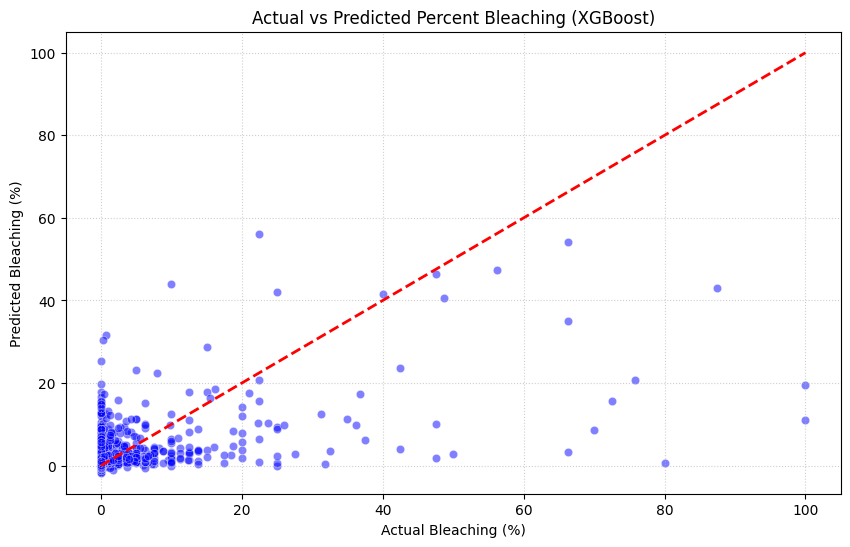

In [142]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_En, y=y_pred_xgb_test, alpha=0.5, color='blue')
plt.plot([y_test_En.min(), y_test_En.max()], [y_test_En.min(), y_test_En.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs Predicted Percent Bleaching (XGBoost)')
plt.xlabel('Actual Bleaching (%)')
plt.ylabel('Predicted Bleaching (%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### ANN model for Future Engineering and delete very relationships

In [143]:
X_trainANN_clean, X_testANN_clean, y_trainANN_clean, y_testANN_clean = Divide_data(feature_En_values, target_En_values, 0.8)
X_trainANN_clean.shape, X_testANN_clean.shape , y_trainANN_clean.shape, y_testANN_clean.shape

((4889, 35), (1223, 35), (4889,), (1223,))

In [144]:
y_trainANN_clean.mean()

2.6988095725097154

In [145]:
y_trainANNpca_scaled.mean()

2.6988095725097154

In [146]:
# ✅ fit เฉพาะ train
X_trainANNclean_scaled = scaler_X.fit_transform(X_trainANN_clean)
X_testANNclean_scaled  = scaler_X.transform(X_testANN_clean)

y_trainANNclean_scaled = scaler_y.fit_transform(y_trainANN_clean.reshape(-1, 1)).flatten()
y_testANNClean_scaled  = scaler_y.transform(y_testANN_clean.reshape(-1, 1)).flatten()

In [147]:
model_ANNClean = model_ANN(X_trainANN_clean)

In [148]:
model_ANNClean.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 64)                2304      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4417 (17.25 KB)
Trainable params: 4417 (17.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [149]:
Error_Clean = K_Fold_cross_validation(model_ANNClean, X_trainANNclean_scaled, y_trainANNclean_scaled)

Fold 1
Epoch 1/64
123/123 [==============================] - 1s 3ms/step - loss: 84.8865 - root_mean_squared_error: 9.2134 - mean_absolute_error: 3.8517 - val_loss: 66.8857 - val_root_mean_squared_error: 8.1784 - val_mean_absolute_error: 3.6379
Epoch 2/64
123/123 [==============================] - 0s 2ms/step - loss: 81.3429 - root_mean_squared_error: 9.0190 - mean_absolute_error: 3.7910 - val_loss: 67.1919 - val_root_mean_squared_error: 8.1971 - val_mean_absolute_error: 3.5386
Epoch 3/64
123/123 [==============================] - 0s 2ms/step - loss: 79.9283 - root_mean_squared_error: 8.9403 - mean_absolute_error: 3.6871 - val_loss: 69.6679 - val_root_mean_squared_error: 8.3467 - val_mean_absolute_error: 3.0940
Epoch 4/64
123/123 [==============================] - 0s 2ms/step - loss: 77.9145 - root_mean_squared_error: 8.8269 - mean_absolute_error: 3.7352 - val_loss: 64.6476 - val_root_mean_squared_error: 8.0404 - val_mean_absolute_error: 3.1724
Epoch 5/64
123/123 [=====================

         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 56.667950 7.527812 3.149958 0.208255
    2 52.741791 7.262354 3.180588 0.428389
    3 63.885216 7.992823 3.242294 0.439642
    4 29.961319 5.473693 2.503545 0.500108
    5 37.685207 6.138828 2.805270 0.581232
  Mean  Loss : 48.1883
  Std   Loss : 13.9783
------------------------------
  Mean  RMSE : 6.8791
  Std   RMSE : 1.0406
------------------------------
  Mean  MAE  : 2.9763
  Std   MAE  : 0.3144
------------------------------
  Mean  R2   : 0.4315
  Std   R2   : 0.1388


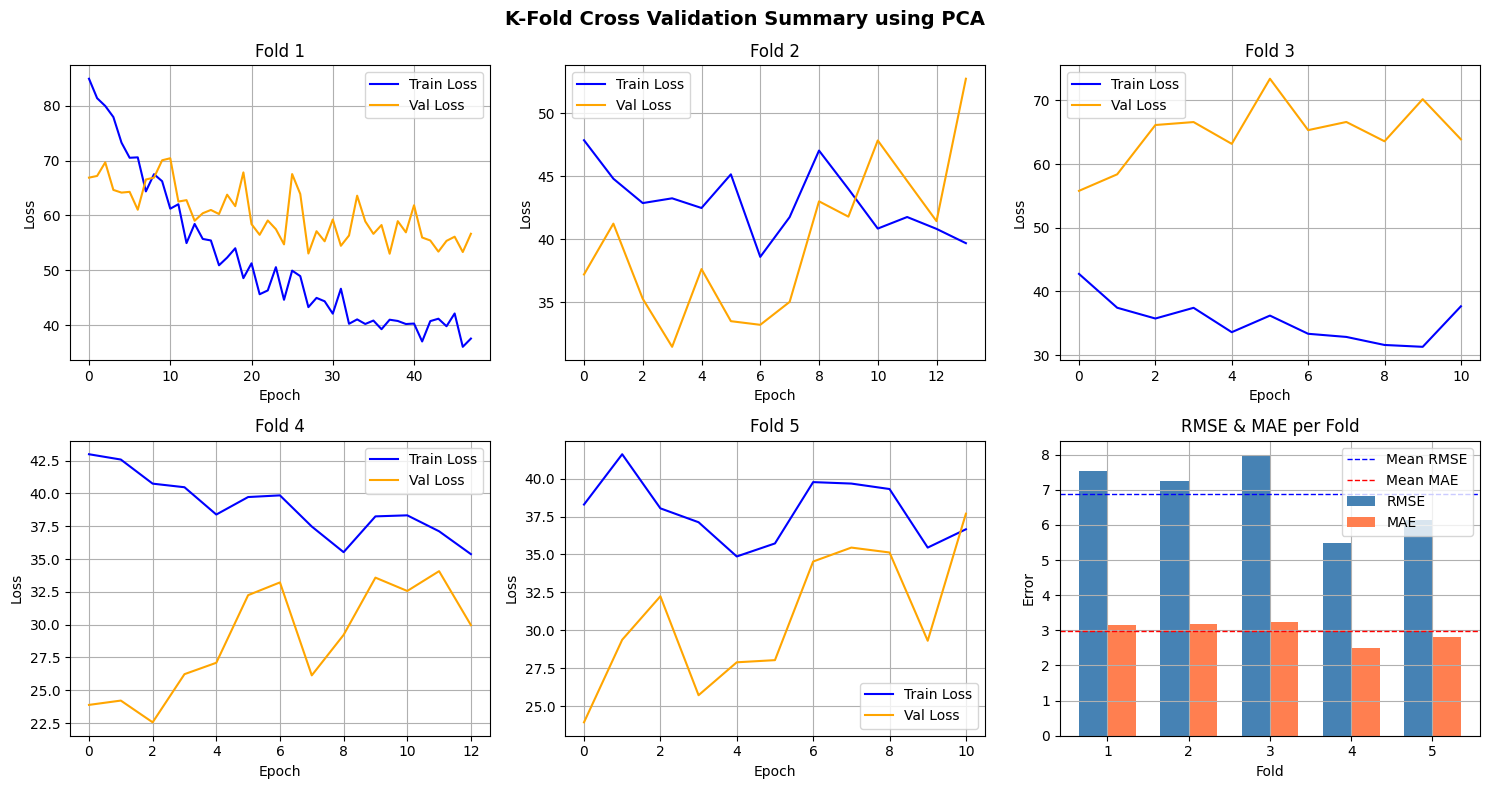

,Fold,Loss,RMSE,MAE,R2
0,1,56.667950,7.527812,3.149958,0.208255
1,2,52.741791,7.262354,3.180588,0.428389
2,3,63.885216,7.992823,3.242294,0.439642
3,4,29.961319,5.473693,2.503545,0.500108
4,5,37.685207,6.138828,2.805270,0.581232


In [150]:
show_kfold_results(Error_Clean)

39/39 [==============================] - 0s 869us/step


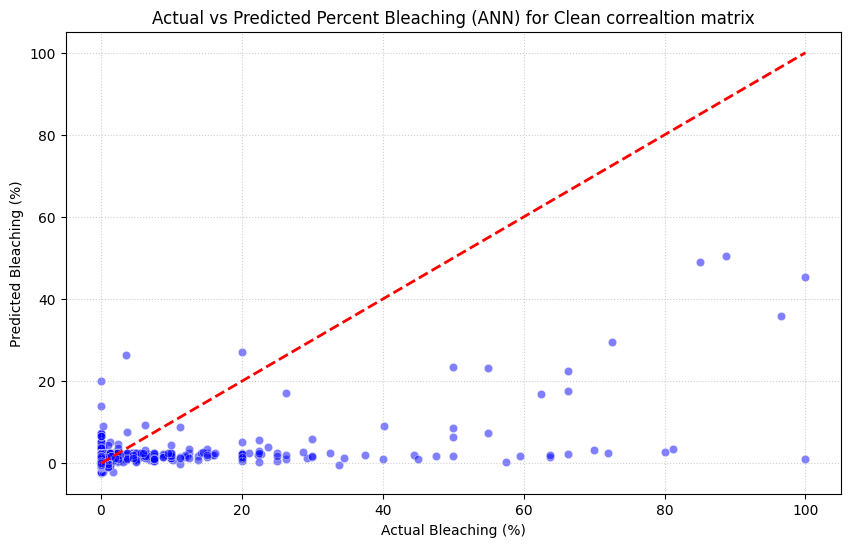

In [151]:
# Predict
y_pred_ANNClean_train = model_ANNClean.predict(X_trainANN_clean)
y_pred_ANNClean_test = model_ANNClean.predict(X_testANNclean_scaled)
y_pred_ANNClean_testtransform = scaler_y.transform(y_pred_ANNClean_test)

# แปลงเป็น 1D
y_pred_ANNClean_testtransform = y_pred_ANNClean_testtransform.ravel()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_testANN_clean,
    y=y_pred_ANNClean_testtransform,
    alpha=0.5,
    color='blue'
)

# เส้น ideal line
plt.plot(
    [y_testANN_clean.min(), y_testANN_clean.max()],
    [y_testANN_clean.min(), y_testANN_clean.max()],
    color='red',
    linestyle='--',
    lw=2
)

plt.title('Actual vs Predicted Percent Bleaching (ANN) for Clean correaltion matrix')
plt.xlabel('Actual Bleaching (%)')
plt.ylabel('Predicted Bleaching (%)')

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [152]:
print(X_train_En.shape)
print(X_trainANN_clean.shape)

(4889, 35)
(4889, 35)


##

## Bottleneck Size

In [153]:
from keras.models import Model
from keras.layers import Input, Dense

# ── โมเดล ────────────────────────────────
def build_autoencoder(X_train):

    INPUT_DIM      = X_train.shape[1]
    BOTTLENECK_DIM = 10

    inputs = Input(shape=(INPUT_DIM,), name="Input")

    x = Dense(64, activation='relu', name="Encoder_1")(inputs)
    x = Dense(32, activation='relu', name="Encoder_2")(x)

    bottleneck = Dense(BOTTLENECK_DIM, activation='linear',
                       name="Bottleneck")(x)

    x = Dense(32, activation='relu', name='Decoder_1')(bottleneck)
    x = Dense(64, activation='relu', name='Decoder_2')(x)

    # ✅ linear — ไม่จำกัด range ของ output
    outputs = Dense(INPUT_DIM, activation='linear', name='Output')(x)

    return Model(inputs=inputs, outputs=outputs, name="Autoencoder")

# ── เทรน ─────────────────────────────────
autoencoder = build_autoencoder(X_trainANNclean_scaled)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 35)]              0         
                                                                 
 Encoder_1 (Dense)           (None, 64)                2304      
                                                                 
 Encoder_2 (Dense)           (None, 32)                2080      
                                                                 
 Bottleneck (Dense)          (None, 10)                330       
                                                                 
 Decoder_1 (Dense)           (None, 32)                352       
                                                                 
 Decoder_2 (Dense)           (None, 64)                2112      
                                                                 
 Output (Dense)              (None, 35)               

In [154]:
X_tr, X_val = train_test_split(
    X_trainANNclean_scaled,
    test_size    = 0.2,
    random_state = 42
)

# ใช้ train loss แทน
early_stopping = EarlyStopping(
    monitor  = 'loss',  # ← ใช้ train loss แทน
    patience = 10,
    restore_best_weights = True
)

history = autoencoder.fit(
    X_tr, X_tr,
    validation_split = 0.2,   # ← เพิ่มตรงนี้
    epochs     = 32,
    batch_size = 32,
    callbacks  = [early_stopping],
    verbose    = 1
)

Epoch 1/32
98/98 [==============================] - 1s 3ms/step - loss: 1.4434 - val_loss: 0.7072
Epoch 2/32
98/98 [==============================] - 0s 2ms/step - loss: 0.5937 - val_loss: 0.4390
Epoch 3/32
98/98 [==============================] - 0s 2ms/step - loss: 0.3965 - val_loss: 0.3393
Epoch 4/32
98/98 [==============================] - 0s 2ms/step - loss: 0.2990 - val_loss: 0.2675
Epoch 5/32
98/98 [==============================] - 0s 2ms/step - loss: 0.2398 - val_loss: 0.2285
Epoch 6/32
98/98 [==============================] - 0s 2ms/step - loss: 0.2058 - val_loss: 0.1974
Epoch 7/32
98/98 [==============================] - 0s 2ms/step - loss: 0.1843 - val_loss: 0.1799
Epoch 8/32
98/98 [==============================] - 0s 2ms/step - loss: 0.1695 - val_loss: 0.1630
Epoch 9/32
98/98 [==============================] - 0s 2ms/step - loss: 0.1539 - val_loss: 0.1535
Epoch 10/32
98/98 [==============================] - 0s 2ms/step - loss: 0.1427 - val_loss: 0.1453
Epoch 11/32
98/98 [

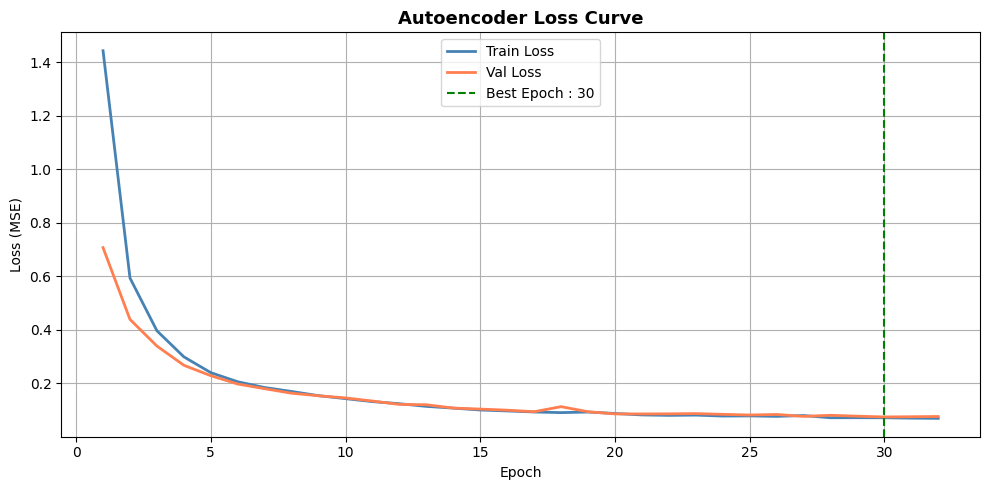

  Best Epoch      : 30
  Best Val Loss   : 0.0742
  Final Train Loss: 0.0691
  Final Val Loss  : 0.0760


In [155]:
import matplotlib.pyplot as plt

def plot_autoencoder_loss(history):
    
    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']
    epochs     = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_loss, label='Train Loss', color='steelblue',  linewidth=2)
    plt.plot(epochs, val_loss,   label='Val Loss',   color='coral',      linewidth=2)
    
    # จุด loss ต่ำสุด
    best_epoch = val_loss.index(min(val_loss)) + 1
    plt.axvline(x=best_epoch, color='green', linestyle='--', 
                label=f'Best Epoch : {best_epoch}')

    plt.title("Autoencoder Loss Curve", fontsize=13, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # สรุปตัวเลข
    print("=" * 40)
    print(f"  Best Epoch      : {best_epoch}")
    print(f"  Best Val Loss   : {min(val_loss):.4f}")
    print(f"  Final Train Loss: {train_loss[-1]:.4f}")
    print(f"  Final Val Loss  : {val_loss[-1]:.4f}")
    print("=" * 40)

# เรียกใช้
plot_autoencoder_loss(history)

In [156]:
# ดึง compressed features จาก Bottleneck layer
bottleneck_model = Model(
    inputs  = autoencoder.input,
    outputs = autoencoder.get_layer("Bottleneck").output
)

# แปลง X เป็น Bottleneck features
X_train_bottleneck = bottleneck_model.predict(X_trainANNclean_scaled)
X_test_bottleneck  = bottleneck_model.predict(X_testANNclean_scaled)

print(f"X_train shape เดิม      : {X_trainANNclean_scaled.shape}")
print(f"X_train shape Bottleneck : {X_train_bottleneck.shape}")

39/39 [==============================] - 0s 868us/step
X_train shape เดิม      : (4889, 35)
X_train shape Bottleneck : (4889, 10)


In [157]:
# ✅ input_shape เปลี่ยนจาก 33 → 10
def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(10,)),  # ← 10 แทน 33
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    return model

model_reshape = build_model()
model_reshape.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                704       
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_12 (Dense)            (None, 1)                 33        
                                                                 
Total params: 2817 (11.00 KB)
Trainable params: 2817 (11.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [158]:
Error_bottleneck = K_Fold_cross_validation(model_reshape,X_train_bottleneck, y_trainANNclean_scaled)

Fold 1
Epoch 1/64
123/123 [==============================] - 1s 3ms/step - loss: 88.4920 - root_mean_squared_error: 9.4070 - mean_absolute_error: 3.8885 - val_loss: 69.7847 - val_root_mean_squared_error: 8.3537 - val_mean_absolute_error: 4.2709
Epoch 2/64
123/123 [==============================] - 0s 2ms/step - loss: 85.8094 - root_mean_squared_error: 9.2633 - mean_absolute_error: 3.9111 - val_loss: 69.1294 - val_root_mean_squared_error: 8.3144 - val_mean_absolute_error: 3.3122
Epoch 3/64
123/123 [==============================] - 0s 2ms/step - loss: 86.3070 - root_mean_squared_error: 9.2902 - mean_absolute_error: 3.7799 - val_loss: 67.7395 - val_root_mean_squared_error: 8.2304 - val_mean_absolute_error: 3.7883
Epoch 4/64
123/123 [==============================] - 0s 2ms/step - loss: 85.5823 - root_mean_squared_error: 9.2511 - mean_absolute_error: 3.8743 - val_loss: 67.8025 - val_root_mean_squared_error: 8.2342 - val_mean_absolute_error: 3.7989
Epoch 5/64
123/123 [=====================

         K-Fold Cross Validation Results
 Fold       Loss      RMSE      MAE       R2
    1  63.421768  7.963778 3.405035 0.113893
    2  70.717407  8.409365 3.801382 0.233571
    3 102.551125 10.126753 4.138580 0.100491
    4  46.449139  6.815361 3.195892 0.225015
    5  67.372795  8.208094 3.753969 0.251336
  Mean  Loss : 70.1024
  Std   Loss : 20.4013
------------------------------
  Mean  RMSE : 8.3047
  Std   RMSE : 1.1911
------------------------------
  Mean  MAE  : 3.6590
  Std   MAE  : 0.3668
------------------------------
  Mean  R2   : 0.1849
  Std   R2   : 0.0717


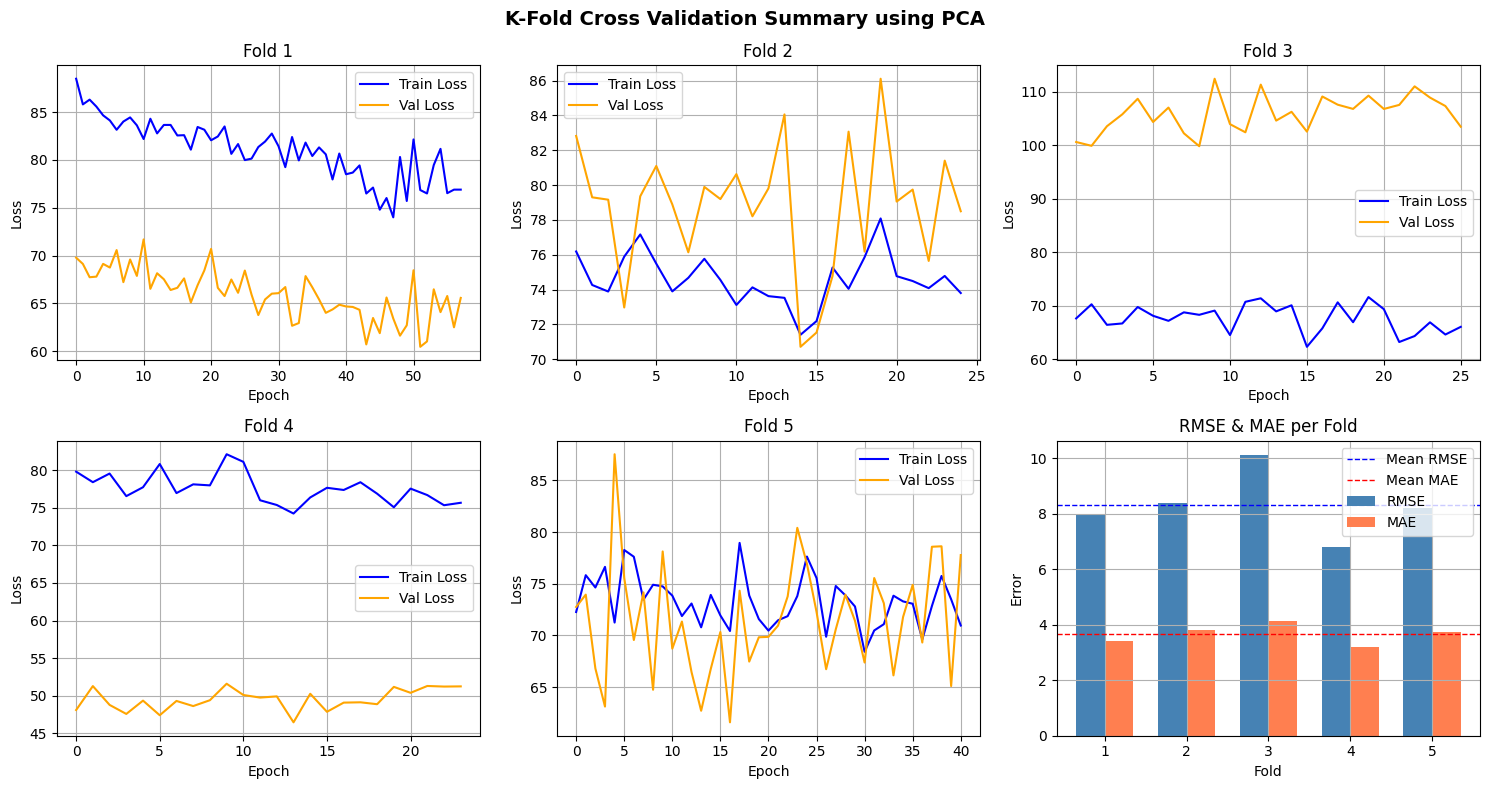

,Fold,Loss,RMSE,MAE,R2
0,1,63.421768,7.963778,3.405035,0.113893
1,2,70.717407,8.409365,3.801382,0.233571
2,3,102.551125,10.126753,4.138580,0.100491
3,4,46.449139,6.815361,3.195892,0.225015
4,5,67.372795,8.208094,3.753969,0.251336


In [159]:
show_kfold_results(Error_bottleneck)

In [160]:
from sklearn.feature_selection import SelectKBest, f_regression

# เลือก 10 feature ที่สัมพันธ์กับ y มากที่สุด
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X_trainANNclean_scaled, y_trainANNclean_scaled)

# ดูว่าเลือก feature ไหน
selected_idx = selector.get_support(indices=True)
print(f"Feature ที่เลือก : {selected_idx}")

print(f"Shape เดิม   : {X_trainANNclean_scaled.shape}")
print(f"Shape ใหม่   : {X_selected.shape}")

Feature ที่เลือก : [10 12 14 17 24 26 28 29 30 31]
Shape เดิม   : (4889, 35)
Shape ใหม่   : (4889, 10)


In [161]:
# เช็คก่อนเลยครับ
print(type(X_trainANNclean_scaled))
print(X_trainANNclean_scaled.shape)
print(f"mean : {X_trainANNclean_scaled.mean():.4f}")
print(f"std  : {X_trainANNclean_scaled.std():.4f}")
print(f"min  : {X_trainANNclean_scaled.min():.4f}")
print(f"max  : {X_trainANNclean_scaled.max():.4f}")

<class 'numpy.ndarray'>
(4889, 35)
mean : 0.1910
std  : 1.4557
min  : -9.8117
max  : 49.7931


In [162]:
print(f"X_tr  shape : {X_tr.shape}")
print(f"X_val shape : {X_val.shape}")
print(f"X_tr  mean  : {X_tr.mean():.4f}  std : {X_tr.std():.4f}")
print(f"X_val mean  : {X_val.mean():.4f}  std : {X_val.std():.4f}")

X_tr  shape : (3911, 35)
X_val shape : (978, 35)
X_tr  mean  : 0.1870  std : 1.4285
X_val mean  : 0.2071  std : 1.5593


In [163]:
stats = pd.DataFrame({
    'mean' : X_trainANNclean_scaled.mean(axis=0),
    'std'  : X_trainANNclean_scaled.std(axis=0),
    'min'  : X_trainANNclean_scaled.min(axis=0),
    'max'  : X_trainANNclean_scaled.max(axis=0)
}).round(4)

print(stats.sort_values('max', ascending=False).head(10))

      mean     std     min      max
31  1.0710  3.0800  0.0000  49.7931
17  0.8805  2.4702  0.0000  35.8857
23  0.6100  2.1172  0.0000  31.0300
16  0.0827  2.4613 -1.5000  28.5000
30  0.4875  1.4691 -0.7357  24.8677
21  0.3316  1.4248  0.0000  22.3900
27  0.3777  1.3273 -0.6798  21.9811
24  0.3838  1.2539 -0.3975  21.5116
15  0.1902  0.8298 -1.3288  16.3288
22  0.7206  1.2674  0.0000  13.1229


In [164]:
# ดูชื่อ feature ที่ index 28
print(df_final.columns[28])

# หรือถ้าเป็น numpy array
print(f"Feature 28 คือคอลัมน์ที่ 28 ของ X_trainANNClean")

TSA_FrequencyMax
Feature 28 คือคอลัมน์ที่ 28 ของ X_trainANNClean


In [165]:
# เช็คค่าของ Depth และ SSTA_DHW ก่อน
print("Depth :")
print(df_final['Depth_m'].describe())

print("\nSSTA_DHW :")
print(df_final['SSTA_DHW'].describe())

# เช็คการคูณ
df_final['Stability_check'] = df_final['Depth_m'] * df_final['SSTA_DHW']
print("\nDepth * SSTA_DHW :")
print(df_final['Stability_check'].describe())

Depth :
count    6112.000000
mean        6.471188
std         3.467763
min         0.100000
25%         4.000000
50%         6.000000
75%        10.000000
max        23.000000
Name: Depth_m, dtype: float64

SSTA_DHW :
count    6112.000000
mean        3.153033
std         4.082572
min         0.000000
25%         0.000000
50%         1.918750
75%         4.602500
max        38.450000
Name: SSTA_DHW, dtype: float64

Depth * SSTA_DHW :
count    6112.000000
mean       20.271130
std        29.228739
min         0.000000
25%         0.000000
50%        10.090000
75%        27.610000
max       313.460000
Name: Stability_check, dtype: float64


## Two-stage model

In [166]:
# ── Stage 1 : Classification ──────────────────────
# มี bleaching หรือไม่?
y_binary = (y_trainANN > 0).astype(int)

model_clf = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # ← binary output
])

model_clf.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ── Stage 2 : Regression ──────────────────────────
# เฉพาะ sample ที่มี bleaching (y > 0)
mask = y_trainANN > 0

model_reg = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)  # ← regression output
])

model_reg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=[RootMeanSquaredError(name='rmse'), 'mae']
)

# ── Predict รวม ───────────────────────────────────
def predict_two_stage(X, model_clf, model_reg, scaler_y, threshold=0.5):
    
    prob    = model_clf.predict(X).flatten()
    is_bleaching = (prob >= threshold).astype(int)
    
    y_reg   = model_reg.predict(X).flatten()
    y_reg   = inverse_y(y_reg, scaler_y)  # inverse log + scale
    
    y_final = np.where(is_bleaching == 0, 0, y_reg)
    
    return y_final

NameError: name 'y_trainANN' is not defined